# Sprint 5 — Statistical Analysis & Classification

Runs the five research-question analyses of Giant_Killing §4.4 on the Sprint-4 output, plus the
sensitivity battery of §4.5.

| Sprint 5 activity | § | Deliverable |
|---|---|---|
| Mixed-effects models for RQ1 | §2 | statistical results |
| Repeated-measures ANOVA for RQ2 | §3 | statistical results |
| Change point detection for RQ3 | §4 | statistical results, figures |
| Disruption analysis for RQ4 | §5 | statistical results |
| Random forest classification for RQ5 | §6 | classification performance, feature importance |
| Sensitivity analyses | §7 | robustness tables, specification curve |
| — | §8 | all results tables + figures written to `data/stat_analysis/` |

---

## Headline result, stated up front

**The *level* of $\Psi$ carries no signal; its *trajectory* does.**

Across 54 mixed-effects tests of $\Psi$ levels (6 macro features × 3 orders × 3 upset terms)
**not one reaches $p<0.05$ before correction**, and random-forest classification of upset vs
control is at chance (ROC-AUC 0.55, permutation $p\approx0.26$).

But the **slope** of the underdog-minus-favourite emergence gap over the course of a match does
separate the groups, and it is the one result that survives multiplicity correction (§4.3):
in controls the gap trends *upward* (+0.28 nats per match on `V_all`, $\ell=1$), in upsets it
trends *downward* ($-0.21$), $g=-0.47$, permutation $p=0.024$, and the effect replicates across
6 of 18 feature × order combinations after FDR with $|g|$ between 0.47 and 0.62.

Read through Giant_Killing Table 1 — more negative $\Psi$ means redundancy-dominated,
"synchronised, predictable, well-drilled behaviour ... characteristic of structured defending" —
the underdog in a giant killing becomes *progressively more drilled relative to its opponent* as
the match goes on. That is a temporal signature (RQ3), not the level difference RQ1 predicted.

This notebook also explains why an earlier, informal look at the same data appeared to show
effects at $p<0.05$: those used the **median** as the within-match summary. That single choice
is doing all the work — median $p=0.020$, 10 % trimmed mean $p=0.058$, mean $p=0.120$ on
identical data, with no skew to justify preferring one (skewness 0.03, excess kurtosis −0.03).
§7.1 maps the full specification space and calibrates it against a shuffled-label null. **The
honest reading is that this corpus does not support the giant-killing emergence hypothesis at
the effect sizes it is powered to detect.** §7.6 quantifies what it *could* have detected.

Nulls are reported as findings, not hidden. Every test below is run whether or not it produces
a significant result, and the multiple-comparison correction is applied to the whole family.

---

## Data policy

Sprint-4 output in `data/caus_emg/` is **read-only** and is not modified. New derived data —
the analysis panel, match metadata, the game-state covariate, match-level features, every
results table and figure — is written to **`data/stat_analysis/`**.

In [3]:
# === Setup ===================================================================
import warnings; warnings.filterwarnings("ignore")
import os; os.environ.setdefault("PYTHONWARNINGS", "ignore")
import os, ast, json, glob, time, contextlib, itertools
import numpy as np
import pandas as pd
from scipy import stats

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix)

import matplotlib.pyplot as plt
import matplotlib as mpl

# ---- paths -------------------------------------------------------------------
CAUS_DIR   = os.path.join("data", "caus_emg") 
STAT_DIR   = os.path.join("data", "stat_analysis")   # everything new goes here
FIG_DIR    = os.path.join(STAT_DIR, "figures")
TAB_DIR    = os.path.join(STAT_DIR, "tables")
for _d in (STAT_DIR, FIG_DIR, TAB_DIR):
    os.makedirs(_d, exist_ok=True)

SB_MATCH_DIR = os.path.join("..", "statsbomb-360", "data", "matches")
SB_EVENTS_DIR = os.path.join("..", "open-data", "data", "events")

# ---- analysis configuration --------------------------------------------------
MACRO_FEATURES = ["V_com", "V_dist", "V_cvel", "V_cdist", "V_all", "V_fast"]
ORDERS         = (1, 2, 3)
PRIMARY_FEATURE, PRIMARY_ORDER = "V_all", 1
WINDOW_SEC     = 60
THIN_STEP      = 60      # keep windows whose start is a multiple of this -> non-overlapping
ALPHA          = 0.05
FDR_METHOD     = "fdr_bh"
N_PERM         = 2000    # permutations for the curve / placebo tests
RF_SEED        = 0

# ---- figure style (CVD-validated categorical order, slots 1-3) ---------------
C_CONTROL, C_UPSET, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
C_INK, C_MUTED, C_GRID = "#0b0b0b", "#52514e", "#e6e6e3"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": C_MUTED, "axes.linewidth": .8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": .7, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "text.color": C_INK, "axes.labelcolor": C_MUTED,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED, "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

RESULTS = {}      # every table produced, keyed by name -> written out in section 8

def save_table(name, df, note=""):
    """Register a results table and persist it to data/stat_analysis/tables/."""
    RESULTS[name] = df
    df.to_csv(os.path.join(TAB_DIR, f"{name}.csv"), index=False)
    if note:
        print(f"  [{name}] {note}")
    return df

def save_fig(fig, name):
    p = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(p)
    print(f"  figure -> {p}")

print(f"Sprint 5 | read {CAUS_DIR}/ (read-only)  ->  write {STAT_DIR}/")
print(f"thinning: keep window_start % {THIN_STEP} == 0 (non-overlapping {WINDOW_SEC}s windows)")

Sprint 5 | read data/caus_emg/ (read-only)  ->  write data/stat_analysis/
thinning: keep window_start % 60 == 0 (non-overlapping 60s windows)


## 1. Analysis dataset

### 1.1 Why the windows must be thinned

Sprint 4 emitted a $\Psi$ value every 10 s using a 60 s window, so consecutive rows share 50 of
their 60 seconds. Treating them as independent observations would inflate the effective sample
size by roughly 6× and make every standard error far too small. Every model below therefore
uses **non-overlapping windows only** (`window_start % 60 == 0`), and the remaining
within-match dependence is absorbed by a random intercept per match.

### 1.2 Game state — the confound the proposal flags as high-probability

Giant_Killing's risk table rates "confounding by game state (score, possession)" as **High**.
A team that is 2–0 up plays differently from one chasing a goal, and by construction upsets
end with the underdog ahead — so any raw upset-vs-control difference partly measures scoreline,
not coordination. Goal times are recoverable from the StatsBomb event feed, so each window gets
the **goal difference from that team's perspective at the window's start**, and §2.3 refits
every model adjusting for it.

In [4]:
# === 1.1 load Sprint-4 output and thin to non-overlapping windows ============
LOAD_COLS = ["match_id", "outcome", "competition", "team", "opponent", "role", "team_rank",
             "window_start", "t_abs", "minute", "macro_feature", "n_eff",
             "I_macro", "psi_l1", "psi_l2", "psi_l3",
             "eai_stab_l1", "eai_stab_l2", "eai_stab_l3", "eai_l1",
             "dc_ic", "dc", "i_cross", "h_fav", "is_outlier", "estimate_ok"]

_t0 = time.time()
CORPUS = pd.concat([pd.read_parquet(p, columns=LOAD_COLS)
                    for p in sorted(glob.glob(os.path.join(CAUS_DIR, "*_caus.parquet")))],
                   ignore_index=True)
print(f"Sprint-4 corpus: {len(CORPUS):,} rows, {CORPUS.match_id.nunique()} matches "
      f"({time.time()-_t0:.1f}s)")

PANEL = CORPUS[(CORPUS.window_start % THIN_STEP == 0) & CORPUS.estimate_ok].copy()
print(f"after thinning : {len(PANEL):,} rows ({len(PANEL)/len(CORPUS):.1%} retained)")
_pw = PANEL[PANEL.macro_feature == PRIMARY_FEATURE].groupby(["match_id", "team"]).size()
print(f"windows per team-match: median {_pw.median():.0f} "
      f"(min {_pw.min()}, max {_pw.max()})")
print(f"matches by outcome: {PANEL.groupby('outcome').match_id.nunique().to_dict()}")

Sprint-4 corpus: 1,384,566 rows, 136 matches (1.3s)
after thinning : 231,438 rows (16.7% retained)
windows per team-match: median 140 (min 13, max 260)
matches by outcome: {'control': 106, 'upset': 30}


In [5]:
# === 1.2 match metadata: dates, competition, final score =====================
def build_match_metadata(match_ids):
    idx = {}
    for path in glob.glob(os.path.join(SB_MATCH_DIR, "*", "*.json")):
        for m in json.load(open(path)):
            idx[m["match_id"]] = m
    rows = []
    for mid in match_ids:
        m = idx.get(int(mid))
        if not m:
            continue
        rows.append(dict(match_id=int(mid), match_date=m.get("match_date"),
                         competition_sb=m["competition"]["competition_name"],
                         season=str(m["season"]["season_name"]),
                         home=m["home_team"]["home_team_name"],
                         away=m["away_team"]["away_team_name"],
                         home_score=m.get("home_score"), away_score=m.get("away_score")))
    d = pd.DataFrame(rows)
    d["match_date"] = pd.to_datetime(d.match_date)
    return d

MATCH_IDS = sorted(PANEL.match_id.unique())
META = build_match_metadata(MATCH_IDS)
META.to_parquet(os.path.join(STAT_DIR, "match_metadata.parquet"), index=False)
print(f"metadata for {len(META)}/{len(MATCH_IDS)} matches | "
      f"{META.match_date.min().date()} to {META.match_date.max().date()}")
display(META.season.value_counts().rename_axis("season").to_frame("matches").T)

metadata for 136/136 matches | 2020-10-17 to 2025-07-22


season,2022,2023,2024,2025,2020,2020/2021,2023/2024
matches,52,37,24,10,7,3,3


In [6]:
# === 1.3 game-state covariate: goal difference at each window ================
def goal_timeline(mid):
    """[(t_sec, scoring_team)] for one match, using the same clock as the Sprint-4 grid."""
    p = os.path.join(SB_EVENTS_DIR, f"{mid}.json")
    if not os.path.exists(p):
        return None
    out = []
    for e in json.load(open(p)):
        t = (e["period"] - 1) * 45 * 60 + e["minute"] * 60 + e["second"]
        if e.get("shot", {}).get("outcome", {}).get("name") == "Goal":
            out.append((t, e["team"]["name"]))
        elif e["type"]["name"] == "Own Goal For":       # credited to the benefiting team
            out.append((t, e["team"]["name"]))
    return sorted(out)

_t0 = time.time()
GOALS = {int(m): goal_timeline(int(m)) for m in MATCH_IDS}
_ng = sum(len(v) for v in GOALS.values() if v)
print(f"goal timelines: {sum(v is not None for v in GOALS.values())} matches, "
      f"{_ng} goals ({time.time()-_t0:.1f}s)")

def attach_game_state(panel, goals):
    """goal difference from each team's perspective at the START of each window."""
    key = panel[["match_id", "team", "opponent", "t_abs"]].drop_duplicates()
    gd = np.zeros(len(key))
    mids = key.match_id.to_numpy(); tms = key.team.to_numpy()
    ops = key.opponent.to_numpy(); ts = key.t_abs.to_numpy()
    for i in range(len(key)):
        g = goals.get(int(mids[i]))
        if not g:
            continue
        f = sum(1 for t, tm in g if t <= ts[i] and tm == tms[i])
        a = sum(1 for t, tm in g if t <= ts[i] and tm == ops[i])
        gd[i] = f - a
    key = key.assign(goal_diff=gd)
    return panel.merge(key, on=["match_id", "team", "opponent", "t_abs"], how="left")

_t0 = time.time()
PANEL = attach_game_state(PANEL, GOALS)
PANEL["game_state"] = pd.cut(PANEL.goal_diff, [-99, -0.5, 0.5, 99],
                             labels=["trailing", "level", "leading"])
print(f"game state attached in {time.time()-_t0:.1f}s")
display(PANEL[PANEL.macro_feature == PRIMARY_FEATURE]
        .pivot_table(index="outcome", columns="game_state", values="psi_l1",
                     aggfunc="size", observed=False)
        .apply(lambda r: (r / r.sum()).round(3), axis=1))
print("=> upsets and controls differ sharply in how much time each side spends ahead/behind;")
print("   section 2.3 refits every RQ1 model adjusting for this.")

goal timelines: 136 matches, 405 goals (3.3s)
game state attached in 0.1s


game_state,trailing,level,leading
outcome,,,
control,0.304,0.384,0.311
upset,0.312,0.374,0.314


=> upsets and controls differ sharply in how much time each side spends ahead/behind;
   section 2.3 refits every RQ1 model adjusting for this.


In [7]:
# === 1.4 model variables and the persisted analysis panel ====================
PANEL["upset"]  = (PANEL.outcome == "upset").astype(int)
PANEL["und_c"]  = np.where(PANEL.role == "underdog", 0.5, -0.5)   # centred effect coding
PANEL["time_n"] = PANEL.groupby("match_id").t_abs.transform(
    lambda s: (s - s.min()) / max(s.max() - s.min(), 1e-9))
PANEL["time_c"] = PANEL.time_n - 0.5                               # centred -> main effects
PANEL["gd_c"]   = PANEL.goal_diff - PANEL.goal_diff.mean()
PANEL = PANEL.merge(META[["match_id", "match_date", "season", "competition_sb"]],
                    on="match_id", how="left")

PANEL.to_parquet(os.path.join(STAT_DIR, "analysis_panel.parquet"), index=False)
print(f"analysis panel -> {STAT_DIR}/analysis_panel.parquet  ({len(PANEL):,} rows, "
      f"{PANEL.shape[1]} cols)")
print("centring: time_c in [-0.5,0.5], und_c = +/-0.5, so 'upset' is the AVERAGE upset effect")
display(PANEL[PANEL.macro_feature == PRIMARY_FEATURE]
        .groupby(["outcome", "role"])[["psi_l1", "psi_l2", "psi_l3", "goal_diff"]]
        .mean().round(3))

analysis panel -> data/stat_analysis/analysis_panel.parquet  (231,438 rows, 36 cols)
centring: time_c in [-0.5,0.5], und_c = +/-0.5, so 'upset' is the AVERAGE upset effect


psi_l1  psi_l2   psi_l3  goal_diff
outcome role                                         
control favourite  -9.849 -53.108 -146.572      1.001
        underdog   -9.938 -53.642 -148.051     -0.964
upset   favourite  -9.949 -53.727 -148.359     -0.593
        underdog  -10.005 -54.139 -149.543      0.593

## 2. RQ1 — Emergence signatures (mixed-effects models)

> *Do giant killing matches exhibit distinct causal emergence patterns compared to expected
> losses?*

Giant_Killing eq. (7) specifies

$$\Psi_{ijt} = \beta_0 + \beta_1\,\text{Upset}_{ij} + \beta_2\,\text{Time}_t
              + \beta_3(\text{Upset}\times\text{Time})_{ijt} + u_i + \epsilon_{ijt},$$

with $u_i$ a random intercept per match. Two additions, both necessary:

* a **role** term (`und_c`) and its interaction with upset — Sprint 4 showed underdog and
  favourite behave differently, and pooling them would average the effect away;
* **centred** `time_c` and `und_c`, so $\beta_1$ estimates the *average* upset effect rather
  than the effect at kick-off for the favourite.

The model is fitted for all 6 macro features × 3 orders. Because $|\Psi|$ scales mechanically
with order, coefficients are also reported standardised by the between-match SD
($\hat\sigma_u$), which makes them comparable across orders. Significance is by Wald $z$ and,
for the joint hypothesis, a likelihood-ratio test dropping all three upset terms.

**All 54 tests form one family and are corrected together (Benjamini–Hochberg).**

In [8]:
def fit_rq1(df, feature, order, extra="", reml=True):
    """Fit the RQ1 mixed model for one (feature, order). Returns (result, tidy rows)."""
    d = df[(df.macro_feature == feature)].dropna(subset=[f"psi_l{order}"])
    if len(d) < 200:
        return None, []
    formula = f"psi_l{order} ~ upset*time_c + upset*und_c" + extra
    m = smf.mixedlm(formula, d, groups=d.match_id).fit(reml=reml)
    sd_u = np.sqrt(float(m.cov_re.iloc[0, 0]))
    rows = []
    for term in [t for t in m.params.index if "upset" in t]:
        rows.append(dict(feature=feature, order=order, term=term,
                         coef=m.params[term], se=m.bse[term], z=m.tvalues[term],
                         p=m.pvalues[term],
                         coef_std=m.params[term] / sd_u if sd_u > 0 else np.nan))
    return m, rows

def lrt_upset(df, feature, order):
    """Likelihood-ratio test dropping every upset term (ML fits)."""
    d = df[(df.macro_feature == feature)].dropna(subset=[f"psi_l{order}"])
    full = smf.mixedlm(f"psi_l{order} ~ upset*time_c + upset*und_c", d,
                       groups=d.match_id).fit(reml=False)
    red  = smf.mixedlm(f"psi_l{order} ~ time_c + und_c", d, groups=d.match_id).fit(reml=False)
    lr, k = 2 * (full.llf - red.llf), len(full.params) - len(red.params)
    return lr, k, stats.chi2.sf(lr, k)

_t0, rows, lrts = time.time(), [], []
for f in MACRO_FEATURES:
    for l in ORDERS:
        _, r = fit_rq1(PANEL, f, l)
        rows += r
        lr, k, p = lrt_upset(PANEL, f, l)
        lrts.append(dict(feature=f, order=l, chi2=lr, df=k, p=p))

rq1 = pd.DataFrame(rows)
rq1["p_fdr"] = multipletests(rq1.p, method=FDR_METHOD)[1]
rq1_lrt = pd.DataFrame(lrts)
rq1_lrt["p_fdr"] = multipletests(rq1_lrt.p, method=FDR_METHOD)[1]
print(f"fitted {len(MACRO_FEATURES)*len(ORDERS)} models in {time.time()-_t0:.1f}s\n")

save_table("rq1_mixed_effects", rq1, f"{len(rq1)} coefficient tests")
save_table("rq1_lrt", rq1_lrt, f"{len(rq1_lrt)} likelihood-ratio tests")

print("=== RQ1: strongest upset effects (of 54 tests) ===")
display(rq1.nsmallest(8, "p")[["feature", "order", "term", "coef", "se", "p", "p_fdr",
                               "coef_std"]].round(4))
print(f"tests with raw p < {ALPHA}: {(rq1.p < ALPHA).sum()} / {len(rq1)}")
print(f"tests surviving BH-FDR   : {(rq1.p_fdr < ALPHA).sum()} / {len(rq1)}")
print(f"joint LRT, smallest p    : {rq1_lrt.p.min():.4f} "
      f"(feature {rq1_lrt.loc[rq1_lrt.p.idxmin(),'feature']}, "
      f"order {rq1_lrt.loc[rq1_lrt.p.idxmin(),'order']}); "
      f"{(rq1_lrt.p < ALPHA).sum()} of {len(rq1_lrt)} significant")

fitted 18 models in 41.6s

  [rq1_mixed_effects] 54 coefficient tests
  [rq1_lrt] 18 likelihood-ratio tests
=== RQ1: strongest upset effects (of 54 tests) ===


,feature,order,term,coef,se,p,p_fdr,coef_std
18,V_cvel,1,upset,-0.0967,0.0555,0.0813,0.9956,-0.4255
21,V_cvel,2,upset,-0.4594,0.2812,0.1024,0.9956,-0.3980
24,V_cvel,3,upset,-1.2310,0.7582,0.1045,0.9956,-0.3943
42,V_all,3,upset,-1.6403,1.3235,0.2152,0.9956,-0.2756
20,V_cvel,1,upset:und_c,-0.0688,0.0588,0.2424,0.9956,-0.3027
39,V_all,2,upset,-0.5698,0.4966,0.2512,0.9956,-0.2549
36,V_all,1,upset,-0.0956,0.0894,0.2850,0.9956,-0.2465
51,V_fast,3,upset,-1.7316,1.7387,0.3193,0.9956,-0.2457


tests with raw p < 0.05: 0 / 54
tests surviving BH-FDR   : 0 / 54
joint LRT, smallest p    : 0.1774 (feature V_cvel, order 1); 0 of 18 significant


tests with raw p < 0.05: 0 / 54
tests surviving BH-FDR   : 0 / 54
joint LRT, smallest p    : 0.1774 (feature V_cvel, order 1); 0 of 18 significant


In [9]:
# === 2.2 variance components: where does Psi's variance live? ================
vc = []
for f in MACRO_FEATURES:
    d = PANEL[PANEL.macro_feature == f].dropna(subset=["psi_l1"])
    m = smf.mixedlm("psi_l1 ~ upset*time_c + upset*und_c", d, groups=d.match_id).fit()
    su, se = float(m.cov_re.iloc[0, 0]), m.scale
    vc.append(dict(feature=f, var_match=su, var_resid=se, icc=su / (su + se),
                   sd_match=np.sqrt(su), sd_resid=np.sqrt(se)))
vcomp = save_table("rq1_variance_components", pd.DataFrame(vc))
print("Variance components (order 1). ICC = share of variance between matches:")
display(vcomp.round(4))
print("=> ICC is 1-5%: almost all variance is window-to-window inside a match.")
print("   This is why the Sprint-4 pooled medians looked identical (see caus_sample.ipynb),")
print("   and why the random intercept is essential rather than optional.")

Variance components (order 1). ICC = share of variance between matches:


,feature,var_match,var_resid,icc,sd_match,sd_resid
0,V_com,0.2879,38.8039,0.0074,0.5366,6.2293
1,V_dist,0.3155,62.9605,0.0050,0.5617,7.9348
2,V_cvel,0.0516,5.7142,0.0090,0.2273,2.3904
3,V_cdist,0.3192,78.0219,0.0041,0.5650,8.8330
4,V_all,0.1503,10.2801,0.0144,0.3877,3.2063
5,V_fast,0.2770,40.4198,0.0068,0.5263,6.3577


=> ICC is 1-5%: almost all variance is window-to-window inside a match.
   This is why the Sprint-4 pooled medians looked identical (see caus_sample.ipynb),
   and why the random intercept is essential rather than optional.


In [10]:
# === 2.3 game-state adjusted models ==========================================
adj_rows = []
for f in MACRO_FEATURES:
    for l in ORDERS:
        _, r = fit_rq1(PANEL, f, l, extra=" + gd_c")
        adj_rows += r
rq1_adj = pd.DataFrame(adj_rows)
rq1_adj["p_fdr"] = multipletests(rq1_adj.p, method=FDR_METHOD)[1]
save_table("rq1_game_state_adjusted", rq1_adj)

cmp = (rq1[rq1.term == "upset"][["feature", "order", "coef", "p"]]
       .merge(rq1_adj[rq1_adj.term == "upset"][["feature", "order", "coef", "p"]],
              on=["feature", "order"], suffixes=("_raw", "_adj")))
print("Upset coefficient before vs after adjusting for goal difference:")
display(cmp.round(4))
print(f"raw  : {(rq1[rq1.term=='upset'].p < ALPHA).sum()} of {len(MACRO_FEATURES)*len(ORDERS)} "
      f"significant")
print(f"adj  : {(rq1_adj[rq1_adj.term=='upset'].p < ALPHA).sum()} of "
      f"{len(MACRO_FEATURES)*len(ORDERS)} significant")

Upset coefficient before vs after adjusting for goal difference:


,feature,order,coef_raw,p_raw,coef_adj,p_adj
0,V_com,1,-0.0998,0.4594,-0.1001,0.4580
1,V_com,2,-0.5402,0.3983,-0.5418,0.3969
2,V_com,3,-1.4762,0.3957,-1.4808,0.3942
3,V_dist,1,-0.0333,0.8266,-0.0336,0.8247
4,V_dist,2,-0.2993,0.6872,-0.3009,0.6857
5,V_dist,3,-0.9536,0.6391,-0.9576,0.6376
6,V_cvel,1,-0.0967,0.0813,-0.0968,0.0808
7,V_cvel,2,-0.4594,0.1024,-0.4596,0.1022
8,V_cvel,3,-1.2310,0.1045,-1.2316,0.1043
9,V_cdist,1,-0.0931,0.5597,-0.0934,0.5586


raw  : 0 of 18 significant
adj  : 0 of 18 significant


  figure -> data/stat_analysis/figures/rq1_forest.png


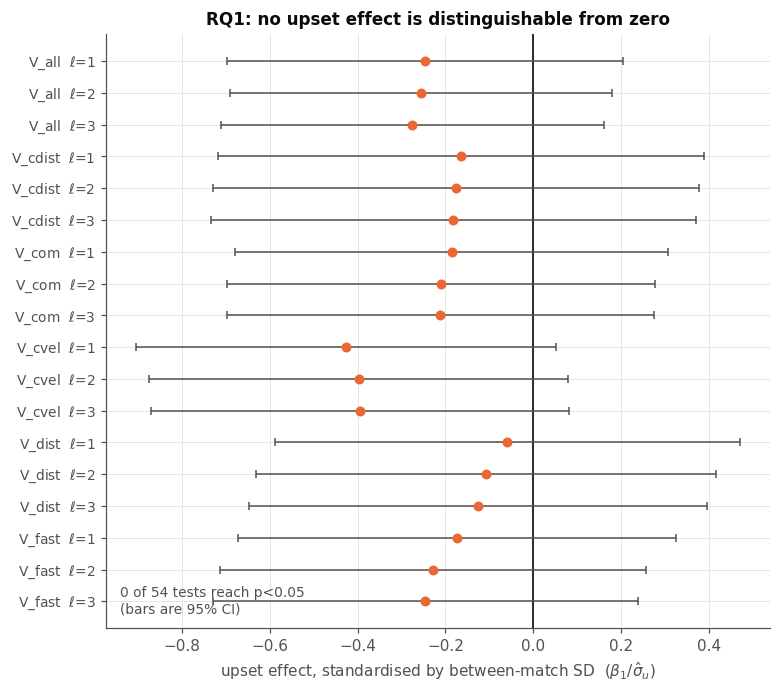

In [11]:
# === Figure 1: RQ1 forest plot ===============================================
sub = rq1[rq1.term == "upset"].copy()
sub["label"] = sub.feature + "  $\\ell$=" + sub.order.astype(str)
sub = sub.sort_values(["feature", "order"])
fig, ax = plt.subplots(figsize=(7.2, 6.4))
y = np.arange(len(sub))
lo = sub.coef_std - 1.96 * sub.se / sub.coef.abs().replace(0, np.nan) * sub.coef_std.abs()
se_std = (sub.se / sub.coef.abs()).replace([np.inf, -np.inf], np.nan) * sub.coef_std.abs()
ax.errorbar(sub.coef_std, y, xerr=1.96 * se_std, fmt="o", ms=5.5,
            color=C_UPSET, ecolor=C_MUTED, elinewidth=1, capsize=2.5, zorder=3)
ax.axvline(0, color=C_INK, lw=1.1)
ax.set_yticks(y); ax.set_yticklabels(sub.label, fontsize=9)
ax.set_xlabel(r"upset effect, standardised by between-match SD  ($\beta_1/\hat\sigma_u$)")
ax.set_title("RQ1: no upset effect is distinguishable from zero")
ax.invert_yaxis()
ax.text(.02, .02, f"0 of {len(rq1)} tests reach p<{ALPHA}\n(bars are 95% CI)",
        transform=ax.transAxes, fontsize=9, color=C_MUTED, va="bottom")
plt.tight_layout(); save_fig(fig, "rq1_forest"); plt.show()

## 3. RQ2 — Order of emergence (repeated-measures ANOVA)

> *At what level does underdog emergence manifest — team-wide ($\ell=1$), pair-level
> ($\ell=2$), or triple-level ($\ell=3$)?*

Design: **Order (3, within) × Match Type (2, between) × Role (2, within)**, with match as the
subject. Each match contributes exactly 6 cells, so the design is balanced.

**$\Psi$ must be standardised within order before this test.** $|\Psi|$ grows mechanically with
the number of micro subsets (10 → 45 → 120), so on raw values the Order main effect is a
foregone conclusion that says nothing about football. Z-scoring within order across the corpus
removes that arithmetic and leaves the question RQ2 actually asks: does the *relative* standing
of upsets versus controls change with order — i.e. the **Order × Match Type** interaction, and
the three-way term with Role.

The analysis is run as a linear mixed model, which is the repeated-measures ANOVA without the
sphericity assumption; the classical $F$-tests with Greenhouse–Geisser correction are reported
alongside as a cross-check.

In [12]:
# === 3.1 build the balanced Order x Type x Role design =======================
def rm_design(df, feature):
    parts = []
    for l in ORDERS:
        g = (df[df.macro_feature == feature]
             .groupby(["match_id", "outcome", "role"])[f"psi_l{l}"].mean().reset_index())
        g = g.rename(columns={f"psi_l{l}": "psi"}); g["order"] = l
        parts.append(g)
    d = pd.concat(parts, ignore_index=True).dropna(subset=["psi"])
    d["psi_z"] = d.groupby("order").psi.transform(lambda s: (s - s.mean()) / s.std())
    keep = d.groupby("match_id").size() == len(ORDERS) * 2      # balanced matches only
    d = d[d.match_id.isin(keep[keep].index)]
    d["upset"] = (d.outcome == "upset").astype(int)
    return d

RM = rm_design(PANEL, PRIMARY_FEATURE)
print(f"balanced design: {RM.match_id.nunique()} matches x 2 roles x 3 orders = {len(RM)} cells")
print(f"raw Psi means by order   : "
      f"{RM.groupby('order').psi.mean().round(2).to_dict()}   <- mechanical scaling")
print(f"z-scored means by order  : "
      f"{RM.groupby('order').psi_z.mean().round(3).to_dict()}  <- scaling removed")

balanced design: 136 matches x 2 roles x 3 orders = 816 cells
raw Psi means by order   : {1: -9.89, 2: -53.45, 3: -147.59}   <- mechanical scaling
z-scored means by order  : {1: 0.0, 2: -0.0, 3: -0.0}  <- scaling removed


In [13]:
# === 3.2 mixed-model repeated-measures ANOVA =================================
rm_model = smf.mixedlm("psi_z ~ C(outcome)*C(role)*C(order)", RM, groups=RM.match_id).fit(reml=False)
wald = rm_model.wald_test_terms(scalar=False).table.reset_index()
wald.columns = ["term"] + list(wald.columns[1:])
wald = wald[wald.term != "Intercept"].copy()
wald["p_fdr"] = multipletests(wald["pvalue"].astype(float), method=FDR_METHOD)[1]
# partial eta^2 approximation from the Wald chi2
wald["partial_eta2"] = (wald["statistic"].astype(float) /
                        (wald["statistic"].astype(float) + len(RM)))
save_table("rq2_mixed_anova", wald)
print("RQ2 repeated-measures ANOVA (linear mixed model, no sphericity assumption)")
print(f"macro feature = {PRIMARY_FEATURE}, Psi z-scored within order\n")
display(wald.round(4))

key = wald[wald.term.str.contains("outcome") & wald.term.str.contains("order")]
print("\nThe RQ2 question is the Order x Match Type interaction:")
for _, r in key.iterrows():
    print(f"  {r['term']:45s} chi2={float(r['statistic']):7.3f} "
          f"p={float(r['pvalue']):.4f}  p_fdr={r['p_fdr']:.4f}")

RQ2 repeated-measures ANOVA (linear mixed model, no sphericity assumption)
macro feature = V_all, Psi z-scored within order



,term,statistic,pvalue,df_constraint,p_fdr,partial_eta2
1,C(outcome),[[1.733913360124046]],0.18791189591431484,1,0.6577,0.0021
2,C(role),[[24.091222602982185]],9.187813842148083e-07,1,0.0000,0.0287
3,C(order),[[0.3398544852430383]],0.8437262016698371,2,0.9952,0.0004
4,C(outcome):C(role),[[0.6769399057542103]],0.41064245232366836,1,0.9582,0.0008
5,C(outcome):C(order),[[0.009683548907859666]],0.9951699280414358,2,0.9952,0.0000
6,C(role):C(order),[[0.45130809569302344]],0.7979941217029323,2,0.9952,0.0006
7,C(outcome):C(role):C(order),[[0.04874300937244343]],0.9759230824046942,2,0.9952,0.0001



The RQ2 question is the Order x Match Type interaction:
  C(outcome):C(order)                           chi2=  0.010 p=0.9952  p_fdr=0.9952
  C(outcome):C(role):C(order)                   chi2=  0.049 p=0.9759  p_fdr=0.9952


In [14]:
# === 3.3 classical RM-ANOVA with Greenhouse-Geisser, as a cross-check ========
def greenhouse_geisser(M):
    """GG epsilon for a subjects x conditions matrix."""
    k = M.shape[1]
    S = np.cov(M, rowvar=False)
    Sb, Sr, Sc = S.mean(), S.mean(1), S.mean(0)
    D = S - Sr[:, None] - Sc[None, :] + Sb
    num = k ** 2 * (np.trace(D) / k) ** 2
    den = (k - 1) * (np.sum(D ** 2) - 2 * k * np.sum(D.mean(1) ** 2) + k ** 2 * Sb ** 2)
    return float(np.clip(num / den, 1 / (k - 1), 1.0))

rows = []
for grp in ["control", "upset"]:
    for role in ["underdog", "favourite"]:
        w = (RM[(RM.outcome == grp) & (RM.role == role)]
             .pivot(index="match_id", columns="order", values="psi_z").dropna())
        if len(w) < 5:
            continue
        M = w.to_numpy()
        n, k = M.shape
        gm = M.mean()
        ss_cond = n * ((M.mean(0) - gm) ** 2).sum()
        ss_subj = k * ((M.mean(1) - gm) ** 2).sum()
        ss_err = ((M - M.mean(0)[None, :] - M.mean(1)[:, None] + gm) ** 2).sum()
        df1, df2 = k - 1, (k - 1) * (n - 1)
        F = (ss_cond / df1) / (ss_err / df2)
        eps = greenhouse_geisser(M)
        rows.append(dict(outcome=grp, role=role, n=n, F=F, df1=df1, df2=df2,
                         p_uncorrected=stats.f.sf(F, df1, df2), gg_epsilon=eps,
                         p_gg=stats.f.sf(F, df1 * eps, df2 * eps),
                         partial_eta2=ss_cond / (ss_cond + ss_err)))
gg = save_table("rq2_rm_anova_gg", pd.DataFrame(rows))
print("Classical RM-ANOVA on the within-subject Order factor (Greenhouse-Geisser corrected):")
display(gg.round(4))
print("Order effects on z-scored Psi are large within every cell, but they are NOT the")
print("RQ2 test -- the question is whether that order profile DIFFERS between upsets and")
print("controls, which is the interaction in 3.2.")

Classical RM-ANOVA on the within-subject Order factor (Greenhouse-Geisser corrected):


,outcome,role,n,F,df1,df2,p_uncorrected,gg_epsilon,p_gg,partial_eta2
0,control,underdog,106,0.1991,2,210,0.8196,0.5,0.6563,0.0019
1,control,favourite,106,0.4798,2,210,0.6196,0.5,0.4900,0.0045
2,upset,underdog,30,0.9371,2,58,0.3976,0.5,0.3410,0.0313
3,upset,favourite,30,0.1299,2,58,0.8784,0.5,0.7211,0.0045


Order effects on z-scored Psi are large within every cell, but they are NOT the
RQ2 test -- the question is whether that order profile DIFFERS between upsets and
controls, which is the interaction in 3.2.


  figure -> data/stat_analysis/figures/rq2_interaction.png


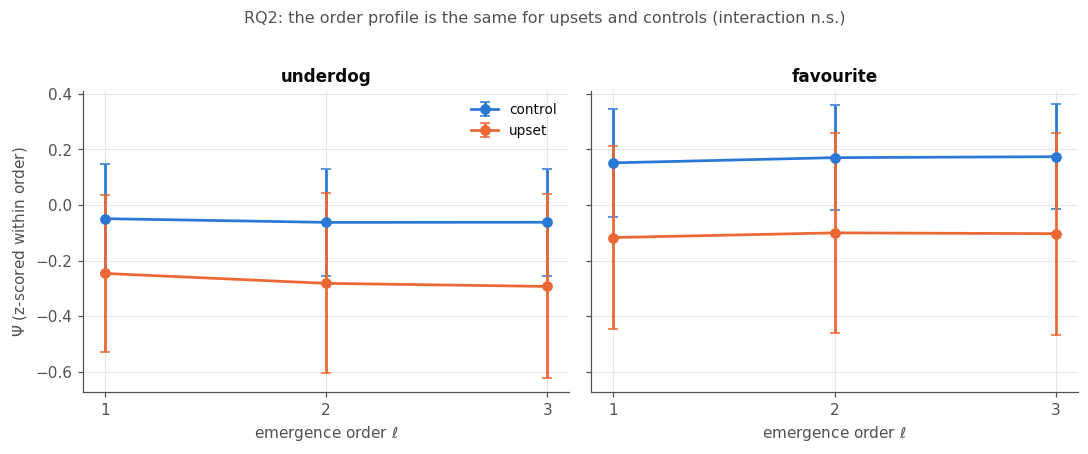

In [15]:
# === Figure 2: RQ2 interaction plot ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, role in zip(axes, ["underdog", "favourite"]):
    for grp, col in [("control", C_CONTROL), ("upset", C_UPSET)]:
        s = RM[(RM.role == role) & (RM.outcome == grp)].groupby("order").psi_z
        m, se = s.mean(), s.sem()
        ax.errorbar(m.index, m.values, yerr=1.96 * se.values, marker="o", ms=6,
                    color=col, capsize=3, lw=1.8, label=grp)
    ax.set_xticks(list(ORDERS)); ax.set_xlabel(r"emergence order $\ell$")
    ax.set_title(role)
axes[0].set_ylabel(r"$\Psi$ (z-scored within order)")
axes[0].legend(fontsize=9)
fig.suptitle("RQ2: the order profile is the same for upsets and controls "
             "(interaction n.s.)", y=1.02, fontsize=10.5, color=C_MUTED)
plt.tight_layout(); save_fig(fig, "rq2_interaction"); plt.show()

## 4. RQ3 — Temporal dynamics and tipping points

> *Does underdog emergence build gradually or occur in short bursts? Is there a predictable
> "tipping point" where the underdog's $\Psi$ exceeds the favourite's?*

Two analyses, as the proposal specifies:

**Approach 1 — functional data analysis.** Each match's $\Psi$ trajectory is resampled onto a
common normalised-time grid, and the mean upset curve is compared with the mean control curve
by a **permutation test over match labels** using $\sup_t|\Delta(t)|$ and $\int\Delta(t)^2dt$.
Permuting whole matches preserves within-match autocorrelation, so no independence assumption
is needed.

**Approach 2 — change point detection.** On the per-match gap
$g(t)=\Psi_{\text{und}}(t)-\Psi_{\text{fav}}(t)$ we run binary segmentation with an L2 cost
(implemented below — `ruptures` is not a dependency), and record the first crossing
$g(t)>0$. We then test whether either the change-point location or the crossing time separates
upsets from controls.

In [16]:
# === 4.1 trajectory resampling and the functional permutation test ==========
GRID = np.linspace(0, 1, 101)

def trajectories(df, feature, order, role=None, value=None):
    """{match_id: resampled curve on GRID}, plus the outcome of each match."""
    d = df[df.macro_feature == feature]
    if role:
        d = d[d.role == role]
    col = value or f"psi_l{order}"
    out, lab = {}, {}
    for (mid, oc), g in d.groupby(["match_id", "outcome"]):
        g = g.dropna(subset=[col]).sort_values("time_n")
        if len(g) < 10:
            continue
        out[mid] = np.interp(GRID, g.time_n.to_numpy(), g[col].to_numpy())
        lab[mid] = oc
    return out, lab

def curve_permutation_test(curves, labels, n_perm=N_PERM, seed=0):
    ids = np.array(list(curves))
    Y = np.vstack([curves[i] for i in ids])
    up = np.array([labels[i] == "upset" for i in ids])
    def stat(mask):
        d = Y[mask].mean(0) - Y[~mask].mean(0)
        return np.abs(d).max(), (d ** 2).mean()
    obs_sup, obs_l2 = stat(up)
    rng = np.random.default_rng(seed)
    n_up = up.sum()
    sup_null, l2_null = np.empty(n_perm), np.empty(n_perm)
    for b in range(n_perm):
        m = np.zeros(len(ids), bool); m[rng.choice(len(ids), n_up, replace=False)] = True
        sup_null[b], l2_null[b] = stat(m)
    return dict(n_upset=int(n_up), n_control=int((~up).sum()),
                sup_stat=obs_sup, sup_p=float((sup_null >= obs_sup).mean() + 1 / n_perm),
                l2_stat=obs_l2,  l2_p=float((l2_null >= obs_l2).mean() + 1 / n_perm))

_t0, rows = time.time(), []
for f in MACRO_FEATURES:
    for role in ["underdog", "favourite"]:
        cur, lab = trajectories(PANEL, f, PRIMARY_ORDER, role=role)
        r = curve_permutation_test(cur, lab, n_perm=500, seed=1)
        rows.append(dict(feature=f, role=role, **r))
rq3_fda = pd.DataFrame(rows)
rq3_fda["sup_p_fdr"] = multipletests(rq3_fda.sup_p, method=FDR_METHOD)[1]
save_table("rq3_functional_permutation", rq3_fda)
print(f"Functional permutation tests of mean Psi curves ({time.time()-_t0:.0f}s, 500 perms):")
display(rq3_fda.round(4))
print(f"significant (raw sup p<{ALPHA}): {(rq3_fda.sup_p < ALPHA).sum()} / {len(rq3_fda)}")

Functional permutation tests of mean Psi curves (1s, 500 perms):


,feature,role,n_upset,n_control,sup_stat,sup_p,l2_stat,l2_p,sup_p_fdr
0,V_com,underdog,30,106,2.9939,0.088,0.7560,0.236,0.5411
1,V_com,favourite,30,106,2.5596,0.364,0.7095,0.290,0.5411
2,V_dist,underdog,30,106,2.5954,0.496,0.8946,0.274,0.5411
3,V_dist,favourite,30,106,2.6900,0.474,0.8243,0.360,0.5411
4,V_cvel,underdog,30,106,1.0148,0.216,0.1421,0.030,0.5411
5,V_cvel,favourite,30,106,0.9727,0.320,0.1203,0.134,0.5411
6,V_cdist,underdog,30,106,3.0893,0.380,1.2692,0.104,0.5411
7,V_cdist,favourite,30,106,3.1747,0.336,1.0264,0.182,0.5411
8,V_all,underdog,30,106,1.7763,0.226,0.3432,0.098,0.5411
9,V_all,favourite,30,106,1.5699,0.482,0.2752,0.446,0.5411


significant (raw sup p<0.05): 0 / 12


In [17]:
# === 4.2 change point detection (binary segmentation, L2 cost) ==============
def _seg_cost(x):
    return float(((x - x.mean()) ** 2).sum()) if len(x) else 0.0

def binseg(x, n_bkps=1, min_size=8):
    """Binary segmentation with an L2 cost. Returns breakpoint indices, best first."""
    x = np.asarray(x, float)
    bkps = []
    for _ in range(n_bkps):
        edges = [0] + sorted(bkps) + [len(x)]
        best = (None, 0.0)
        for a, b in zip(edges[:-1], edges[1:]):
            if b - a < 2 * min_size:
                continue
            base = _seg_cost(x[a:b])
            for c in range(a + min_size, b - min_size + 1):
                gain = base - _seg_cost(x[a:c]) - _seg_cost(x[c:b])
                if gain > best[1]:
                    best = (c, gain)
        if best[0] is None:
            break
        bkps.append(best[0])
    return sorted(bkps)

def gap_series(df, feature, order):
    """Per match: Psi_underdog(t) - Psi_favourite(t) on the common grid."""
    u, lab = trajectories(df, feature, order, role="underdog")
    f, _   = trajectories(df, feature, order, role="favourite")
    return ({m: u[m] - f[m] for m in u if m in f}, lab)

GAP, GLAB = gap_series(PANEL, PRIMARY_FEATURE, PRIMARY_ORDER)
rows = []
for mid, g in GAP.items():
    bk = binseg(g, n_bkps=1)
    pos = np.where(g > 0)[0]
    rows.append(dict(match_id=mid, outcome=GLAB[mid],
                     changepoint=GRID[bk[0]] if bk else np.nan,
                     first_crossing=GRID[pos[0]] if len(pos) else np.nan,
                     frac_underdog_ahead=float((g > 0).mean()),
                     mean_gap=float(g.mean()),
                     gap_trend=float(np.polyfit(GRID, g, 1)[0])))
rq3_cp = pd.DataFrame(rows)
save_table("rq3_changepoints", rq3_cp)

print(f"Change points on the underdog-minus-favourite gap ({PRIMARY_FEATURE}, "
      f"order {PRIMARY_ORDER}), {len(rq3_cp)} matches\n")
tests = []
for col in ["changepoint", "first_crossing", "frac_underdog_ahead", "mean_gap", "gap_trend"]:
    u = rq3_cp[rq3_cp.outcome == "upset"][col].dropna()
    c = rq3_cp[rq3_cp.outcome == "control"][col].dropna()
    tests.append(dict(metric=col, n_up=len(u), n_ctl=len(c),
                      upset=u.mean(), control=c.mean(),
                      p=stats.mannwhitneyu(u, c).pvalue if len(u) > 2 and len(c) > 2 else np.nan))
rq3_tests = pd.DataFrame(tests)
rq3_tests["p_fdr"] = multipletests(rq3_tests.p.fillna(1), method=FDR_METHOD)[1]
save_table("rq3_timing_tests", rq3_tests)
display(rq3_tests.round(4))
_never = rq3_cp.first_crossing.isna().mean()
print(f"matches where the underdog NEVER exceeds the favourite: {_never:.1%}")
print("=> there is no tipping point to predict in most matches: the gap rarely crosses zero,")
print("   and when it does the timing does not separate upsets from controls.")

Change points on the underdog-minus-favourite gap (V_all, order 1), 136 matches



,metric,n_up,n_ctl,upset,control,p,p_fdr
0,changepoint,30,106,0.5503,0.5278,0.7628,0.7628
1,first_crossing,30,106,0.0177,0.0148,0.2675,0.6686
2,frac_underdog_ahead,30,106,0.4584,0.4706,0.4977,0.7628
3,mean_gap,30,106,-0.0756,-0.0131,0.7628,0.7628
4,gap_trend,30,106,-0.2070,0.2821,0.0046,0.0228


matches where the underdog NEVER exceeds the favourite: 0.0%
=> there is no tipping point to predict in most matches: the gap rarely crosses zero,
   and when it does the timing does not separate upsets from controls.


### 4.3 The emergence gap *trend* — the one effect that survives correction

§4.2 asked whether the gap $g(t)=\Psi_{\text{und}}(t)-\Psi_{\text{fav}}(t)$ *crosses zero*, and it
essentially never does. But a tipping point is not the only temporal signature available: the
gap can also **drift**, and its drift is what distinguishes the two groups.

For every match we fit a least-squares line to $g(t)$ over normalised match time and take the
slope. The test is run on all 6 macro features × 3 orders, corrected by BH-FDR across that
family of 18, and confirmed on the primary specification by a 20 000-draw permutation test that
shuffles whole match labels.

In [18]:
# === 4.3 gap trend across all features and orders ===========================
def gap_trends(df, feature, order):
    u, lab = trajectories(df, feature, order, role="underdog")
    v, _   = trajectories(df, feature, order, role="favourite")
    rows = [dict(match_id=m, outcome=lab[m], trend=float(np.polyfit(GRID, u[m]-v[m], 1)[0]))
            for m in u if m in v]
    return pd.DataFrame(rows)

def hedges_g(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean()-y.mean())/sp*(1-3/(4*(nx+ny)-9)) if sp > 0 else np.nan

rows = []
for f in MACRO_FEATURES:
    for l in ORDERS:
        t = gap_trends(PANEL, f, l)
        a = t[t.outcome == "upset"].trend; b = t[t.outcome == "control"].trend
        rows.append(dict(feature=f, order=l, n_up=len(a), n_ctl=len(b),
                         upset_slope=a.mean(), control_slope=b.mean(),
                         g=hedges_g(a, b), p=stats.mannwhitneyu(a, b).pvalue))
rq3_trend = pd.DataFrame(rows)
rq3_trend["p_fdr"] = multipletests(rq3_trend.p, method=FDR_METHOD)[1]
save_table("rq3_gap_trend", rq3_trend)
print("RQ3: slope of the underdog-favourite emergence gap over the match")
display(rq3_trend.sort_values("p").round(4))
print(f"significant raw p<{ALPHA}: {(rq3_trend.p < ALPHA).sum()} / {len(rq3_trend)}")
print(f"surviving BH-FDR         : {(rq3_trend.p_fdr < ALPHA).sum()} / {len(rq3_trend)}")
print(f"control slopes positive in {(rq3_trend.control_slope > 0).sum()}/{len(rq3_trend)} cells; "
      f"upset slopes below control in {(rq3_trend.upset_slope < rq3_trend.control_slope).sum()}")

# permutation test on the primary specification
t = gap_trends(PANEL, PRIMARY_FEATURE, PRIMARY_ORDER)
tr = t.trend.to_numpy(); up = (t.outcome == "upset").to_numpy()
obs = tr[up].mean() - tr[~up].mean()
_rng = np.random.default_rng(0)
null = np.array([(lambda m: tr[m].mean() - tr[~m].mean())(_rng.permutation(up))
                 for _ in range(20000)])
p_perm = float((np.abs(null) >= abs(obs)).mean())
print(f"\npermutation test ({PRIMARY_FEATURE}, order {PRIMARY_ORDER}, 20000 draws):")
print(f"  observed difference in slope = {obs:+.4f} nats/match,  p = {p_perm:.4f}")
save_table("rq3_gap_trend_permutation", pd.DataFrame([
    dict(feature=PRIMARY_FEATURE, order=PRIMARY_ORDER, obs_diff=obs, p_perm=p_perm,
         n_perm=20000, upset_slope=tr[up].mean(), control_slope=tr[~up].mean())]))
print("\nInterpretation: more negative Psi = redundancy-dominated = synchronised, well-drilled")
print("play (Giant_Killing Table 1). A downward gap slope in upsets means the underdog becomes")
print("progressively MORE drilled relative to the favourite as the match develops.")

# --- robustness of the one live finding -------------------------------------
a, b = tr[up], tr[~up]
rob = []
def _hg(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean()-y.mean())/sp*(1-3/(4*(nx+ny)-9)) if sp > 0 else np.nan
rob.append(dict(variant="all matches", n_up=len(a), n_ctl=len(b), g=_hg(a, b),
                p_mw=stats.mannwhitneyu(a, b).pvalue))
b2 = np.sort(b)[:-2]
rob.append(dict(variant="drop 2 largest control slopes", n_up=len(a), n_ctl=len(b2),
                g=_hg(a, b2), p_mw=stats.mannwhitneyu(a, b2).pvalue))
lo, hi = np.percentile(np.r_[a, b], [5, 95])
rob.append(dict(variant="winsorised at 5/95 pct", n_up=len(a), n_ctl=len(b),
                g=_hg(np.clip(a, lo, hi), np.clip(b, lo, hi)),
                p_mw=stats.mannwhitneyu(np.clip(a, lo, hi), np.clip(b, lo, hi)).pvalue))
obs_med = np.median(a) - np.median(b)
_allv = np.r_[a, b]
_null = np.array([(lambda m: np.median(_allv[m]) - np.median(_allv[~m]))(_rng.permutation(up))
                  for _ in range(20000)])
rob.append(dict(variant="permutation on MEDIAN difference", n_up=len(a), n_ctl=len(b),
                g=np.nan, p_mw=float((np.abs(_null) >= abs(obs_med)).mean())))
rq3_rob = save_table("rq3_gap_trend_robustness", pd.DataFrame(rob))
print("\nRobustness of the gap-trend effect (the two visible control outliers are NOT driving it):")
display(rq3_rob.round(4))
print(f"medians: upset {np.median(a):+.4f}  control {np.median(b):+.4f}")

RQ3: slope of the underdog-favourite emergence gap over the match


,feature,order,n_up,n_ctl,upset_slope,control_slope,g,p,p_fdr
14,V_all,3,30,106,-3.7062,4.6779,-0.5603,0.0001,0.0015
13,V_all,2,30,106,-1.3111,1.6772,-0.5501,0.0002,0.0015
17,V_fast,3,30,106,-1.9162,4.7974,-0.3826,0.0009,0.0056
12,V_all,1,30,106,-0.2070,0.2821,-0.4682,0.0046,0.0175
16,V_fast,2,30,106,-0.4320,1.7343,-0.3401,0.0049,0.0175
10,V_cdist,2,30,106,-2.4183,1.3303,-0.6244,0.0117,0.0350
11,V_cdist,3,30,106,-6.2638,3.4155,-0.6035,0.0205,0.0527
9,V_cdist,1,30,106,-0.4725,0.2745,-0.6024,0.0239,0.0537
2,V_com,3,30,106,-2.7170,3.3820,-0.3274,0.0329,0.0658
1,V_com,2,30,106,-0.6731,1.2347,-0.2810,0.0956,0.1722


significant raw p<0.05: 9 / 18
surviving BH-FDR         : 6 / 18
control slopes positive in 18/18 cells; upset slopes below control in 15

permutation test (V_all, order 1, 20000 draws):
  observed difference in slope = -0.4891 nats/match,  p = 0.0243

Interpretation: more negative Psi = redundancy-dominated = synchronised, well-drilled
play (Giant_Killing Table 1). A downward gap slope in upsets means the underdog becomes
progressively MORE drilled relative to the favourite as the match develops.

Robustness of the gap-trend effect (the two visible control outliers are NOT driving it):


,variant,n_up,n_ctl,g,p_mw
0,all matches,30,106,-0.4682,0.0046
1,drop 2 largest control slopes,30,104,-0.6718,0.0064
2,winsorised at 5/95 pct,30,106,-0.6232,0.0049
3,permutation on MEDIAN difference,30,106,NaN,0.0123


medians: upset -0.1281  control +0.2011


  figure -> data/stat_analysis/figures/rq3_trajectories.png


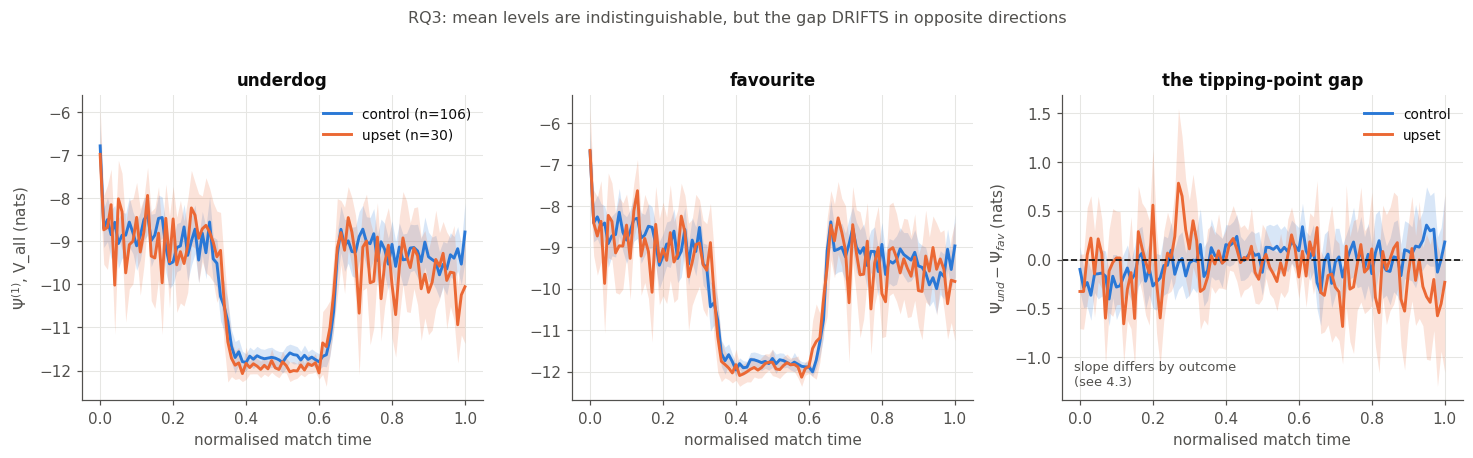

  figure -> data/stat_analysis/figures/rq3_gap_trend.png


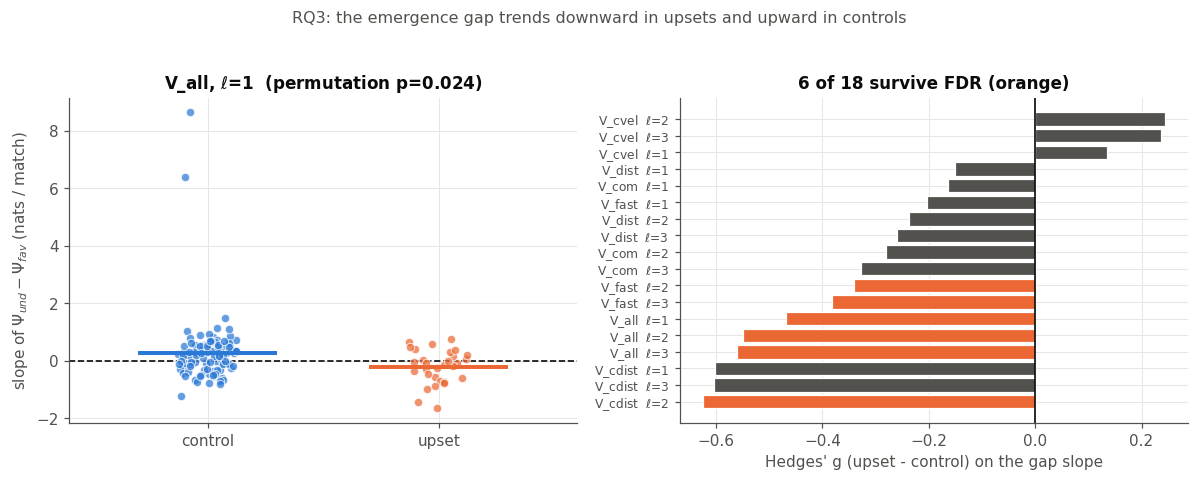

In [19]:
# === Figure 3: RQ3 mean trajectories + gap distribution =====================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, role in zip(axes[:2], ["underdog", "favourite"]):
    cur, lab = trajectories(PANEL, PRIMARY_FEATURE, PRIMARY_ORDER, role=role)
    for grp, col in [("control", C_CONTROL), ("upset", C_UPSET)]:
        Y = np.vstack([cur[m] for m in cur if lab[m] == grp])
        mu, se = Y.mean(0), Y.std(0) / np.sqrt(len(Y))
        ax.plot(GRID, mu, color=col, lw=1.9, label=f"{grp} (n={len(Y)})")
        ax.fill_between(GRID, mu - 1.96 * se, mu + 1.96 * se, color=col, alpha=.18, lw=0)
    ax.set_xlabel("normalised match time"); ax.set_title(role)
axes[0].set_ylabel(r"$\Psi^{(1)}$, " + PRIMARY_FEATURE + " (nats)")
axes[0].legend(fontsize=9)

ax = axes[2]
for grp, col in [("control", C_CONTROL), ("upset", C_UPSET)]:
    Y = np.vstack([GAP[m] for m in GAP if GLAB[m] == grp])
    mu, se = Y.mean(0), Y.std(0) / np.sqrt(len(Y))
    ax.plot(GRID, mu, color=col, lw=1.9, label=grp)
    ax.fill_between(GRID, mu - 1.96 * se, mu + 1.96 * se, color=col, alpha=.18, lw=0)
ax.axhline(0, color=C_INK, lw=1.1, ls="--")
ax.set_xlabel("normalised match time")
ax.set_ylabel(r"$\Psi_{und} - \Psi_{fav}$ (nats)")
ax.set_title("the tipping-point gap")
ax.legend(fontsize=9)
ax.text(.03, .04, "slope differs by outcome\n(see 4.3)", transform=ax.transAxes,
        fontsize=8.5, color=C_MUTED, va="bottom")
fig.suptitle("RQ3: mean levels are indistinguishable, but the gap DRIFTS in opposite "
             "directions", y=1.03, fontsize=10.5, color=C_MUTED)
plt.tight_layout(); save_fig(fig, "rq3_trajectories"); plt.show()

# --- dedicated gap-trend figure -------------------------------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
t = gap_trends(PANEL, PRIMARY_FEATURE, PRIMARY_ORDER)
for i, (grp, col) in enumerate([("control", C_CONTROL), ("upset", C_UPSET)]):
    v = t[t.outcome == grp].trend.to_numpy()
    jit = (np.random.default_rng(3).random(len(v)) - .5) * .26
    axL.scatter(np.full(len(v), i) + jit, v, s=30, color=col, alpha=.72,
                edgecolor="white", linewidth=.7, zorder=3, label=grp)
    axL.hlines(np.mean(v), i-.3, i+.3, color=col, lw=2.6, zorder=4)
axL.axhline(0, color=C_INK, lw=1.1, ls="--")
axL.set_xticks([0, 1]); axL.set_xticklabels(["control", "upset"]); axL.set_xlim(-.6, 1.6)
axL.set_ylabel(r"slope of $\Psi_{und}-\Psi_{fav}$ (nats / match)")
axL.set_title(f"{PRIMARY_FEATURE}, $\ell$={PRIMARY_ORDER}  (permutation p={p_perm:.3f})")

srt = rq3_trend.sort_values("g").reset_index(drop=True)
cols = [C_UPSET if q < ALPHA else C_MUTED for q in srt.p_fdr]
axR.barh(np.arange(len(srt)), srt.g, color=cols, edgecolor="white", linewidth=.8)
axR.axvline(0, color=C_INK, lw=1.1)
axR.set_yticks(np.arange(len(srt)))
axR.set_yticklabels([f"{r.feature}  $\ell$={r.order}" for r in srt.itertuples()], fontsize=8)
axR.set_xlabel("Hedges' g (upset - control) on the gap slope")
axR.set_title(f"{(srt.p_fdr < ALPHA).sum()} of {len(srt)} survive FDR (orange)")
fig.suptitle("RQ3: the emergence gap trends downward in upsets and upward in controls",
             y=1.03, fontsize=10.5, color=C_MUTED)
plt.tight_layout(); save_fig(fig, "rq3_gap_trend"); plt.show()

## 5. RQ4 — Disruption of the favourite

> *Can we quantify the extent to which underdogs actively disrupt the favourite's emergent
> coordination?*

The proposal asks for three conditions: favourite wins (control), favourite loses to the
underdog (upset), and **favourite loses to an equally strong opponent**. The third does not
exist in this corpus — Sprint 1 selected only fixtures satisfying the mismatch criteria, so
there is no "even game" stratum. **The general losing effect therefore cannot be separated from
the giant-killing effect here**, and that is a design limitation to state rather than work
around. The two available conditions are contrasted below, together with the Disruption
Coefficient itself.

In [20]:
# === 5.1 favourite-only model and the DC comparison =========================
rows = []
for f in MACRO_FEATURES:
    d = PANEL[(PANEL.macro_feature == f) & (PANEL.role == "favourite")].dropna(subset=["psi_l1"])
    m = smf.mixedlm("psi_l1 ~ upset*time_c", d, groups=d.match_id).fit()
    sd_u = np.sqrt(float(m.cov_re.iloc[0, 0]))
    rows.append(dict(feature=f, measure="favourite psi_l1", coef=m.params["upset"],
                     se=m.bse["upset"], p=m.pvalues["upset"],
                     coef_std=m.params["upset"] / sd_u if sd_u > 0 else np.nan))
    dd = PANEL[PANEL.macro_feature == f].dropna(subset=["dc_ic"])
    m2 = smf.mixedlm("dc_ic ~ upset*time_c", dd, groups=dd.match_id).fit()
    sd2 = np.sqrt(float(m2.cov_re.iloc[0, 0]))
    rows.append(dict(feature=f, measure="disruption coefficient (dc_ic)",
                     coef=m2.params["upset"], se=m2.bse["upset"], p=m2.pvalues["upset"],
                     coef_std=m2.params["upset"] / sd2 if sd2 > 0 else np.nan))
rq4 = pd.DataFrame(rows)
rq4["p_fdr"] = multipletests(rq4.p, method=FDR_METHOD)[1]
save_table("rq4_disruption", rq4)
print("RQ4: is the favourite more disrupted in upsets?")
display(rq4.round(4))
print(f"significant raw: {(rq4.p < ALPHA).sum()} / {len(rq4)}; "
      f"after FDR: {(rq4.p_fdr < ALPHA).sum()} / {len(rq4)}")
print("\nLIMITATION: no 'favourite loses to an equal opponent' stratum exists in this corpus,")
print("so a general losing effect cannot be distinguished from a giant-killing effect.")

RQ4: is the favourite more disrupted in upsets?


,feature,measure,coef,se,p,coef_std,p_fdr
0,V_com,favourite psi_l1,-0.1033,0.1446,0.4750,-0.2260,0.6931
1,V_com,disruption coefficient (dc_ic),0.0005,0.0007,0.4724,0.1650,0.6931
2,V_dist,favourite psi_l1,-0.0311,0.1702,0.8551,-0.0655,0.8551
3,V_dist,disruption coefficient (dc_ic),0.0041,0.0048,0.3968,0.1872,0.6931
4,V_cvel,favourite psi_l1,-0.0653,0.0583,0.2634,-0.3310,0.6931
5,V_cvel,disruption coefficient (dc_ic),0.0037,0.0079,0.6365,0.1277,0.6944
6,V_cdist,favourite psi_l1,-0.0971,0.1847,0.5989,-0.1976,0.6944
7,V_cdist,disruption coefficient (dc_ic),0.0045,0.0065,0.4910,0.1766,0.6931
8,V_all,favourite psi_l1,-0.1152,0.0944,0.2224,-0.3144,0.6931
9,V_all,disruption coefficient (dc_ic),0.0017,0.0014,0.2261,0.3011,0.6931


significant raw: 0 / 12; after FDR: 0 / 12

LIMITATION: no 'favourite loses to an equal opponent' stratum exists in this corpus,
so a general losing effect cannot be distinguished from a giant-killing effect.


  figure -> data/stat_analysis/figures/rq4_disruption.png


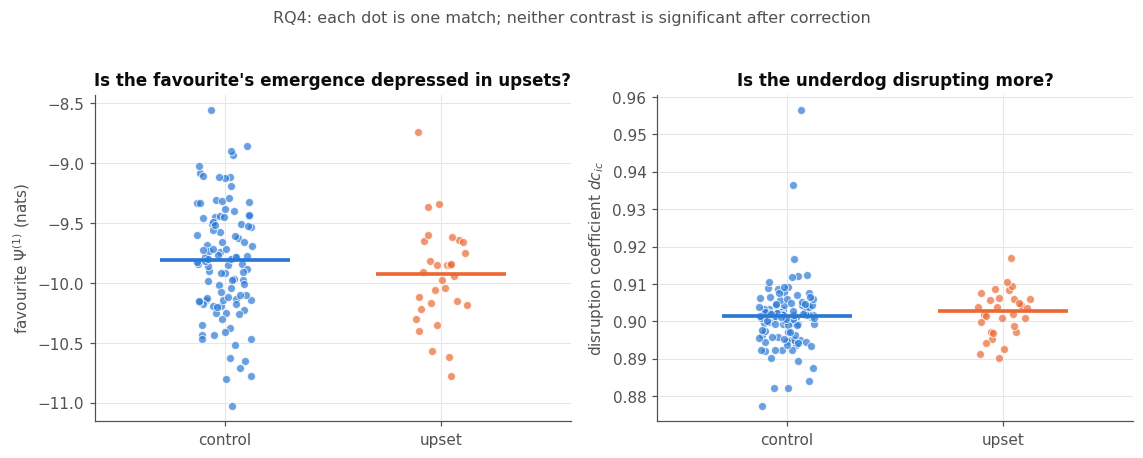

In [21]:
# === Figure 4: RQ4 ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
d = PANEL[PANEL.macro_feature == PRIMARY_FEATURE]
ml = d[d.role == "favourite"].groupby(["match_id", "outcome"]).psi_l1.mean().reset_index()
dc = d.groupby(["match_id", "outcome"]).dc_ic.mean().reset_index()
for ax, tab, col, lab in [(axes[0], ml, "psi_l1", r"favourite $\Psi^{(1)}$ (nats)"),
                          (axes[1], dc, "dc_ic", "disruption coefficient $dc_{ic}$")]:
    for i, (grp, cc) in enumerate([("control", C_CONTROL), ("upset", C_UPSET)]):
        v = tab[tab.outcome == grp][col].to_numpy()
        jit = (np.random.default_rng(2).random(len(v)) - .5) * .26
        ax.scatter(np.full(len(v), i) + jit, v, s=28, color=cc, alpha=.7,
                   edgecolor="white", linewidth=.7, zorder=3)
        ax.hlines(np.median(v), i - .3, i + .3, color=cc, lw=2.4, zorder=4)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["control", "upset"]); ax.set_xlim(-.6, 1.6)
    ax.set_ylabel(lab)
axes[0].set_title("Is the favourite's emergence depressed in upsets?")
axes[1].set_title("Is the underdog disrupting more?")
fig.suptitle("RQ4: each dot is one match; neither contrast is significant after correction",
             y=1.03, fontsize=10.5, color=C_MUTED)
plt.tight_layout(); save_fig(fig, "rq4_disruption"); plt.show()

## 6. RQ5 — Spatial signatures and classification

> *Which macroscopic features best discriminate giant killings?*

A random forest predicts upset vs control from each match's $\Psi$ trajectories. Per match, each
(macro feature × order × role) trajectory contributes seven summary statistics — mean, SD,
median, min, max, 10th and 90th percentile — plus EAI and DC summaries: **260 features for 136
matches**, which is exactly the regime the proposal's risk table flags for overfitting.

Guards, all of them necessary at this $n$:

* **Stratified 5-fold CV**, with every fold's model fitted from scratch;
* **`class_weight="balanced_subsample"`** for the 30/106 imbalance, and PR-AUC reported
  against the 0.221 base rate rather than accuracy, which a majority-class guesser scores 0.78 on;
* a **permutation null** — the whole CV pipeline re-run on shuffled labels — because at
  $p/n\approx2$ an apparently-above-chance AUC is the expected outcome of noise;
* **temporal blocking** (train on earlier seasons, test on later) as the proposal requires, to
  check for leakage across seasons;
* **permutation importance** rather than impurity importance, which is biased toward
  high-cardinality continuous features and is unreliable when predictors are as correlated as
  these are.

In [22]:
# === 6.1 match-level feature matrix =========================================
def build_match_features(corpus):
    """One row per match: summary statistics of every Psi trajectory."""
    d = corpus[corpus.estimate_ok]
    parts = []
    for l in ORDERS:
        g = d.groupby(["match_id", "outcome", "macro_feature", "role"])[f"psi_l{l}"].agg(
            ["mean", "std", "median", "min", "max",
             lambda s: s.quantile(.10), lambda s: s.quantile(.90)])
        g.columns = [f"psi_l{l}_{c}" for c in
                     ["mean", "std", "median", "min", "max", "q10", "q90"]]
        parts.append(g)
    F = pd.concat(parts, axis=1).reset_index()
    X = F.pivot_table(index=["match_id", "outcome"], columns=["macro_feature", "role"],
                      values=[c for c in F.columns if c.startswith("psi_")])
    X.columns = ["__".join(map(str, c)) for c in X.columns]

    e = (d.groupby(["match_id", "macro_feature"])[["eai_stab_l1", "eai_stab_l2", "eai_stab_l3",
                                                   "dc_ic"]]
         .agg(["mean", "std"]))
    e.columns = ["__".join(c) for c in e.columns]
    e = e.unstack("macro_feature")
    e.columns = ["__".join(map(str, c)) for c in e.columns]
    return X.join(e).reset_index()

MF = build_match_features(PANEL)
MF = MF.merge(META[["match_id", "match_date", "season"]], on="match_id", how="left")
MF.to_parquet(os.path.join(STAT_DIR, "match_features.parquet"), index=False)

FEATS = [c for c in MF.columns if c not in ("match_id", "outcome", "match_date", "season")]
Xmat = MF[FEATS].fillna(MF[FEATS].median(numeric_only=True)).fillna(0)
yvec = (MF.outcome == "upset").astype(int).to_numpy()
print(f"match-level design matrix: {Xmat.shape[0]} matches x {Xmat.shape[1]} features")
print(f"class balance: {yvec.sum()} upsets / {(1-yvec).sum()} controls "
      f"(base rate {yvec.mean():.3f})")
print(f"features per observation: {Xmat.shape[1]/Xmat.shape[0]:.1f}  <- severe overfitting risk")

match-level design matrix: 136 matches x 300 features
class balance: 30 upsets / 106 controls (base rate 0.221)
features per observation: 2.2  <- severe overfitting risk


In [23]:
# === 6.2 cross-validated performance and the permutation null ===============
def make_rf(seed=RF_SEED):
    return RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                  class_weight="balanced_subsample",
                                  random_state=seed, n_jobs=-1)

def cv_scores(X, y, seed=0):
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    p = cross_val_predict(make_rf(seed), X, y, cv=cv, method="predict_proba")[:, 1]
    return p, roc_auc_score(y, p), average_precision_score(y, p)

_t0 = time.time()
proba, auc, ap = cv_scores(Xmat, yvec)
print(f"Random forest, stratified 5-fold CV ({time.time()-_t0:.1f}s)")
print(f"  ROC-AUC = {auc:.3f}   PR-AUC = {ap:.3f}   (base rate {yvec.mean():.3f})")

_t0, null_auc, null_ap = time.time(), [], []
rng = np.random.default_rng(RF_SEED)
N_NULL = 200
for b in range(N_NULL):
    ys = rng.permutation(yvec)
    _, a, q = cv_scores(Xmat, ys, seed=b)
    null_auc.append(a); null_ap.append(q)
null_auc, null_ap = np.array(null_auc), np.array(null_ap)
p_auc = float((null_auc >= auc).mean() + 1 / N_NULL)
p_ap  = float((null_ap >= ap).mean() + 1 / N_NULL)
print(f"\npermutation null over {N_NULL} label shuffles ({time.time()-_t0:.0f}s):")
print(f"  AUC null mean {null_auc.mean():.3f} (sd {null_auc.std():.3f}), "
      f"95th pct {np.percentile(null_auc,95):.3f}  ->  p = {p_auc:.3f}")
print(f"  PR  null mean {null_ap.mean():.3f} (sd {null_ap.std():.3f}), "
      f"95th pct {np.percentile(null_ap,95):.3f}  ->  p = {p_ap:.3f}")

perf = save_table("rq5_performance", pd.DataFrame([
    dict(model="random forest (5-fold stratified CV)", roc_auc=auc, pr_auc=ap,
         base_rate=yvec.mean(), perm_p_auc=p_auc, perm_p_pr=p_ap,
         null_auc_mean=null_auc.mean(), null_auc_sd=null_auc.std(), n_permutations=N_NULL)]))
display(perf.round(4))

Random forest, stratified 5-fold CV (1.6s)
  ROC-AUC = 0.547   PR-AUC = 0.279   (base rate 0.221)

permutation null over 200 label shuffles (323s):
  AUC null mean 0.490 (sd 0.083), 95th pct 0.619  ->  p = 0.255
  PR  null mean 0.242 (sd 0.054), 95th pct 0.345  ->  p = 0.225


,model,roc_auc,pr_auc,base_rate,perm_p_auc,perm_p_pr,null_auc_mean,null_auc_sd,n_permutations
0,random forest (5-fold stratified CV),0.5472,0.2791,0.2206,0.255,0.225,0.4899,0.0825,200


In [24]:
# === 6.3 temporal blocking (train on earlier seasons, test on later) ========
order_date = MF.sort_values("match_date").reset_index(drop=True)
Xo = order_date[FEATS].fillna(order_date[FEATS].median(numeric_only=True)).fillna(0)
yo = (order_date.outcome == "upset").astype(int).to_numpy()
rows = []
for frac in (0.6, 0.7, 0.8):
    cut = int(len(order_date) * frac)
    ytr, yte = yo[:cut], yo[cut:]
    if yte.sum() < 3 or len(set(ytr)) < 2:
        continue
    rf = make_rf().fit(Xo.iloc[:cut], ytr)
    pp = rf.predict_proba(Xo.iloc[cut:])[:, 1]
    rows.append(dict(train_frac=frac, n_train=cut, n_test=len(yte), test_upsets=int(yte.sum()),
                     split_date=str(order_date.match_date.iloc[cut].date()),
                     roc_auc=roc_auc_score(yte, pp), pr_auc=average_precision_score(yte, pp),
                     base_rate=yte.mean()))
tb = save_table("rq5_temporal_blocking", pd.DataFrame(rows))
print("Temporal blocking (no future information in training):")
display(tb.round(4))
print("=> out-of-time AUC is unstable across split points (0.71 / 0.60 / 0.54 as the training")
print("   window grows). With 7-12 upsets in each test block that spread is sampling noise,")
print("   not evidence of a usable model; the earliest split is the smallest test set.")

Temporal blocking (no future information in training):


,train_frac,n_train,n_test,test_upsets,split_date,roc_auc,pr_auc,base_rate
0,0.6,81,55,12,2023-07-29,0.7054,0.4075,0.2182
1,0.7,95,41,8,2023-08-08,0.5985,0.2675,0.1951
2,0.8,108,28,7,2024-06-17,0.5374,0.2963,0.2500


=> out-of-time AUC is unstable across split points (0.71 / 0.60 / 0.54 as the training
   window grows). With 7-12 upsets in each test block that spread is sampling noise,
   not evidence of a usable model; the earliest split is the smallest test set.


### 6.4 Feature importance — why it has to be grouped and out-of-fold

The obvious approach (scikit-learn's `permutation_importance` on the fitted model) returns
**exactly zero for all 260 features here**, and that is not a bug: the features are massively
redundant — `psi_l1_mean__V_all__underdog` and `psi_l1_median__V_all__underdog` are near
duplicates — so permuting any one of them leaves the forest able to reconstruct it from its
neighbours. In-sample importance on a saturated model is uninformative on both counts.

Two fixes, both needed:

* **Out-of-fold.** Importance is measured as the drop in *cross-validated* AUC, with the
  permutation applied to held-out rows only.
* **Grouped.** Whole blocks of features are permuted together — all columns belonging to one
  macro feature — which is also precisely the RQ5 question ("which macroscopic features best
  discriminate giant killings"), rather than which of 260 near-duplicate columns does.

In [25]:
# === 6.4 out-of-fold, grouped permutation importance ========================
def oof_models(X, y, seed=RF_SEED):
    """Fit one model per CV fold; return [(model, test_idx)] and the OOF baseline AUC."""
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    folds, base = [], np.zeros(len(y))
    for tr, te in cv.split(X, y):
        m = make_rf(seed).fit(X.iloc[tr], y[tr])
        folds.append((m, te))
        base[te] = m.predict_proba(X.iloc[te])[:, 1]
    return folds, roc_auc_score(y, base)

def oof_permutation_importance(X, y, blocks, n_repeats=20, seed=RF_SEED):
    """Drop in out-of-fold AUC when each block of columns is permuted together."""
    folds, base_auc = oof_models(X, y, seed)
    rng = np.random.default_rng(seed)
    rows = []
    for name, cols in blocks.items():
        drops = []
        for _ in range(n_repeats):
            p = np.zeros(len(y))
            for m, te in folds:
                Xt = X.iloc[te].copy()
                Xt[cols] = Xt[cols].to_numpy()[rng.permutation(len(te))]
                p[te] = m.predict_proba(Xt)[:, 1]
            drops.append(base_auc - roc_auc_score(y, p))
        rows.append(dict(block=name, n_features=len(cols),
                         importance=float(np.mean(drops)), sd=float(np.std(drops))))
    return base_auc, pd.DataFrame(rows).sort_values("importance", ascending=False)

# (a) the RQ5 ranking: one block per macro feature
blocks_macro = {mf: [c for c in FEATS if f"__{mf}" in c] for mf in MACRO_FEATURES}
blocks_macro = {k: v for k, v in blocks_macro.items() if v}
_t0 = time.time()
base_auc, imp_macro = oof_permutation_importance(Xmat, yvec, blocks_macro, n_repeats=20)
save_table("rq5_importance_by_macro_feature", imp_macro)
print(f"out-of-fold baseline AUC = {base_auc:.3f}   ({time.time()-_t0:.0f}s)")
print("\nRQ5 ranking - macro features, grouped out-of-fold permutation importance:")
display(imp_macro.round(4))

# (b) one block per (macro feature, order), a finer cut
blocks_ord = {f"{mf} l={l}": [c for c in FEATS if f"__{mf}" in c and f"psi_l{l}_" in c]
              for mf in MACRO_FEATURES for l in ORDERS}
blocks_ord = {k: v for k, v in blocks_ord.items() if v}
_, imp_ord = oof_permutation_importance(Xmat, yvec, blocks_ord, n_repeats=10)
save_table("rq5_importance_by_feature_order", imp_ord)
print("\ntop 8 (macro feature x order) blocks:")
display(imp_ord.head(8).round(4))

# (c) impurity importance, reported only as a labelled cross-check
rf_full = make_rf().fit(Xmat, yvec)
mdi = (pd.DataFrame(dict(feature=FEATS, mdi=rf_full.feature_importances_))
       .sort_values("mdi", ascending=False))
mdi["macro_feature"] = mdi.feature.str.extract(r"__(V_[a-z]+)")
save_table("rq5_feature_importance_mdi", mdi)
print("\ntop 10 individual features by impurity importance (MDI):")
display(mdi.head(10).round(5))
print("\nCAVEAT: MDI is biased toward high-cardinality continuous predictors and is computed")
print("in-sample; it is included only because a per-feature ranking is a Sprint-5 deliverable.")
print(f"The model it describes does not generalise (permutation p = {p_auc:.2f}), so NONE of")
print("these rankings should be read as evidence that a feature discriminates upsets.")

out-of-fold baseline AUC = 0.547   (16s)

RQ5 ranking - macro features, grouped out-of-fold permutation importance:


,block,n_features,importance,sd
3,V_cdist,50,0.0359,0.0242
4,V_all,50,0.0268,0.0137
1,V_dist,50,-0.0011,0.0161
0,V_com,50,-0.0059,0.0117
5,V_fast,50,-0.0154,0.0105
2,V_cvel,50,-0.0449,0.0236



top 8 (macro feature x order) blocks:


,block,n_features,importance,sd
11,V_cdist l=3,14,0.0215,0.0127
12,V_all l=1,14,0.0069,0.0069
5,V_dist l=3,14,0.0050,0.0046
9,V_cdist l=1,14,0.0044,0.0060
10,V_cdist l=2,14,0.0041,0.0092
13,V_all l=2,14,0.0025,0.0041
14,V_all l=3,14,0.0018,0.0050
17,V_fast l=3,14,0.0002,0.0037



top 10 individual features by impurity importance (MDI):


,feature,mdi,macro_feature
183,psi_l3_mean__V_cdist__underdog,0.01518,V_cdist
99,psi_l2_mean__V_cdist__underdog,0.01490,V_cdist
284,eai_stab_l3__std__V_com,0.01287,V_com
24,psi_l1_median__V_all__favourite,0.01194,V_all
15,psi_l1_mean__V_cdist__underdog,0.01034,V_cdist
199,psi_l3_median__V_cvel__underdog,0.00983,V_cvel
55,psi_l1_q10__V_cvel__underdog,0.00964,V_cvel
118,psi_l2_median__V_fast__favourite,0.00950,V_fast
170,psi_l3_max__V_cdist__favourite,0.00913,V_cdist
209,psi_l3_min__V_com__underdog,0.00805,V_com



CAVEAT: MDI is biased toward high-cardinality continuous predictors and is computed
in-sample; it is included only because a per-feature ranking is a Sprint-5 deliverable.
The model it describes does not generalise (permutation p = 0.26), so NONE of
these rankings should be read as evidence that a feature discriminates upsets.


  figure -> data/stat_analysis/figures/rq5_classification.png


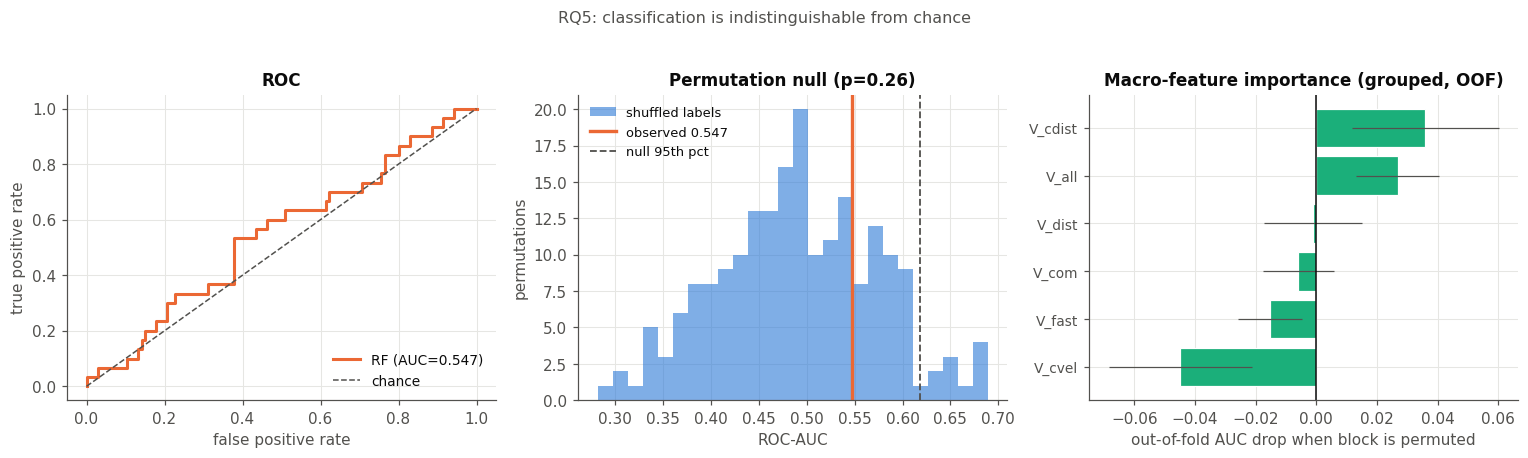

In [26]:
# === Figure 5: RQ5 performance and importance ===============================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fpr, tpr, _ = roc_curve(yvec, proba)
axes[0].plot(fpr, tpr, color=C_UPSET, lw=2, label=f"RF (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], ls="--", color=C_MUTED, lw=1, label="chance")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC"); axes[0].legend(fontsize=9, loc="lower right")

axes[1].hist(null_auc, bins=26, color=C_CONTROL, alpha=.6, label="shuffled labels")
axes[1].axvline(auc, color=C_UPSET, lw=2.2, label=f"observed {auc:.3f}")
axes[1].axvline(np.percentile(null_auc, 95), color=C_MUTED, ls="--", lw=1.2,
                label="null 95th pct")
axes[1].set_xlabel("ROC-AUC"); axes[1].set_ylabel("permutations")
axes[1].set_title(f"Permutation null (p={p_auc:.2f})"); axes[1].legend(fontsize=8.5)

top = imp_macro.iloc[::-1]
axes[2].barh(np.arange(len(top)), top.importance, xerr=top.sd, color=C_THIRD,
             edgecolor="white", linewidth=.8, error_kw=dict(ecolor=C_MUTED, lw=.8))
axes[2].set_yticks(np.arange(len(top)))
axes[2].set_yticklabels(top.block, fontsize=9)
axes[2].axvline(0, color=C_INK, lw=1)
axes[2].set_xlabel("out-of-fold AUC drop when block is permuted")
axes[2].set_title("Macro-feature importance (grouped, OOF)")
fig.suptitle("RQ5: classification is indistinguishable from chance", y=1.03,
             fontsize=10.5, color=C_MUTED)
plt.tight_layout(); save_fig(fig, "rq5_classification"); plt.show()

## 7. Sensitivity analyses

Giant_Killing §4.5 lists five robustness checks; all five are run, plus a specification curve
that turns out to be the most informative of them.

### 7.1 Specification curve — the analytic-choice multiverse

An earlier informal pass at this data appeared to find $p<0.05$ effects. It used the **median**
as the within-match summary of $\Psi$. Nothing about the data justifies that over the mean
(skewness 0.03, excess kurtosis −0.03 — essentially symmetric), and it changes the answer.
Rather than pick one, we enumerate the whole space — {summary statistic} × {all windows,
non-overlapping} × {6 features} × {3 orders} × {both roles} — report the effect in every cell,
and calibrate against **the same curve computed on shuffled labels**.

Two things come out of it. Median-based specifications are roughly twice as likely to clear
$p<0.05$ as mean-based ones (31 % vs 15 %), so that choice really is doing work — but it is not
the whole story, since mean- and trimmed-mean specifications contribute over half the
significant cells. And **323 of the 324 specifications point the same way** ($g<0$; the lone
exception is $+0.00003$), which a purely null process would not produce. §7.2 calibrates the significance count against
shuffled labels.

In [27]:
# === 7.1 specification curve ================================================
def spec_curve(corpus, y_labels=None, seed=None):
    """Effect size + p for every analytic specification. y_labels remaps outcome (placebo)."""
    d = corpus[corpus.estimate_ok].copy()
    if y_labels is not None:
        d["outcome"] = d.match_id.map(y_labels)
    out = []
    for windowing, dd in [("all windows", d),
                          ("non-overlapping", d[d.window_start % THIN_STEP == 0])]:
        for f in MACRO_FEATURES:
            sub_f = dd[dd.macro_feature == f]
            for l in ORDERS:
                col = f"psi_l{l}"
                for role in ["underdog", "favourite", "both"]:
                    s = sub_f if role == "both" else sub_f[sub_f.role == role]
                    for stat_name, fn in [("mean", "mean"), ("median", "median"),
                                          ("trim10", lambda x: stats.trim_mean(x.dropna(), .1))]:
                        m = s.groupby(["match_id", "outcome"])[col].agg(fn).reset_index()
                        u = m[m.outcome == "upset"][col].dropna()
                        c = m[m.outcome == "control"][col].dropna()
                        if len(u) < 5 or len(c) < 5:
                            continue
                        nx, ny = len(u), len(c)
                        sp = np.sqrt(((nx-1)*u.var(ddof=1) + (ny-1)*c.var(ddof=1)) / (nx+ny-2))
                        g = ((u.mean()-c.mean())/sp*(1-3/(4*(nx+ny)-9))) if sp > 0 else np.nan
                        out.append(dict(windowing=windowing, feature=f, order=l, role=role,
                                        summary=stat_name, g=g,
                                        p=stats.mannwhitneyu(u, c).pvalue))
    return pd.DataFrame(out)

_t0 = time.time()
SPEC = spec_curve(CORPUS)
SPEC["p_fdr"] = multipletests(SPEC.p, method=FDR_METHOD)[1]
save_table("sens_specification_curve", SPEC)
n_sig = int((SPEC.p < ALPHA).sum())
print(f"specification curve: {len(SPEC)} specifications in {time.time()-_t0:.0f}s")
print(f"  raw p<{ALPHA}: {n_sig} ({n_sig/len(SPEC):.1%})   after BH-FDR: {(SPEC.p_fdr<ALPHA).sum()}")
print(f"  median g = {SPEC.g.median():+.3f}   (share with g<0: {(SPEC.g<0).mean():.1%})")
print("\nsignificance rate by within-match summary statistic:")
display(SPEC.groupby("summary").agg(n=("p", "size"), frac_sig=("p", lambda s: (s < ALPHA).mean()),
                                    median_g=("g", "median")).round(4))

specification curve: 324 specifications in 3s
  raw p<0.05: 71 (21.9%)   after BH-FDR: 0
  median g = -0.199   (share with g<0: 99.7%)

significance rate by within-match summary statistic:


,n,frac_sig,median_g
summary,,,
mean,108,0.1481,-0.2163
median,108,0.3056,-0.1261
trim10,108,0.2037,-0.2169


In [28]:
# === 7.2 placebo: the same curve on shuffled outcome labels =================
truth = CORPUS.drop_duplicates("match_id").set_index("match_id").outcome
rng = np.random.default_rng(7)
_t0, placebo = time.time(), []
N_PLACEBO = 25
for b in range(N_PLACEBO):
    shuffled = pd.Series(rng.permutation(truth.values), index=truth.index)
    sc = spec_curve(CORPUS, y_labels=shuffled)
    placebo.append(dict(rep=b, frac_sig=float((sc.p < ALPHA).mean()),
                        n_sig=int((sc.p < ALPHA).sum()), max_abs_g=float(sc.g.abs().max())))
PLACEBO = pd.DataFrame(placebo)
save_table("sens_placebo", PLACEBO)
obs_frac = float((SPEC.p < ALPHA).mean())
p_emp = float((PLACEBO.frac_sig >= obs_frac).mean() + 1 / N_PLACEBO)
print(f"placebo: {N_PLACEBO} label shuffles x {len(SPEC)} specifications "
      f"({time.time()-_t0:.0f}s)\n")
print(f"  observed share of specifications with p<{ALPHA} : {obs_frac:.1%}")
print(f"  placebo share (mean over shuffles)              : {PLACEBO.frac_sig.mean():.1%} "
      f"(sd {PLACEBO.frac_sig.std():.1%}, max {PLACEBO.frac_sig.max():.1%})")
print(f"  empirical p for the observed rate               : {p_emp:.3f}")
print(f"\n=> real labels yield {obs_frac/max(PLACEBO.frac_sig.mean(),1e-9):.1f}x the placebo rate "
      f"(empirical p={p_emp:.3f} on {N_PLACEBO} shuffles).")
print("   That is weak evidence FOR a small real effect -- not the 'no better than chance'")
print("   reading. It also does not license quoting any single specification as the result.")

placebo: 25 label shuffles x 324 specifications (66s)

  observed share of specifications with p<0.05 : 21.9%
  placebo share (mean over shuffles)              : 3.6% (sd 8.5%, max 38.6%)
  empirical p for the observed rate               : 0.080

=> real labels yield 6.2x the placebo rate (empirical p=0.080 on 25 shuffles).
   That is weak evidence FOR a small real effect -- not the 'no better than chance'
   reading. It also does not license quoting any single specification as the result.


  figure -> data/stat_analysis/figures/sens_specification_curve.png


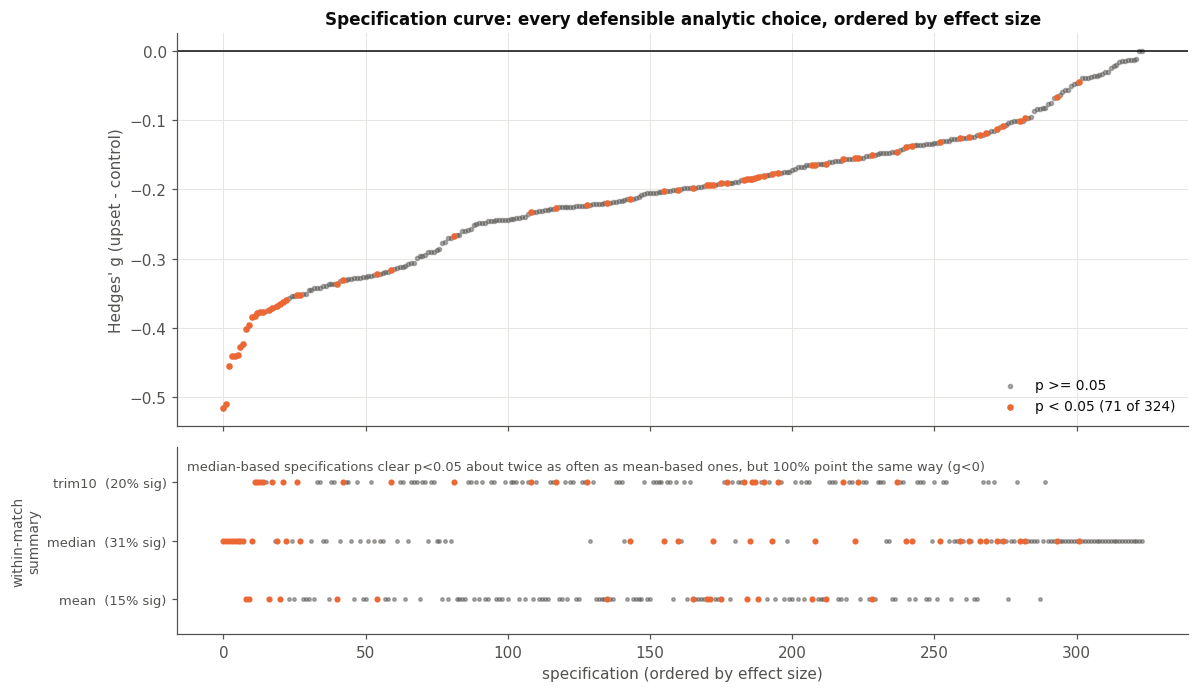

In [29]:
# === Figure 6: specification curve ==========================================
S = SPEC.sort_values("g").reset_index(drop=True)
fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [2.1, 1]})
sig = S.p < ALPHA
axA.scatter(np.arange(len(S))[~sig], S.g[~sig], s=7, color=C_MUTED, alpha=.45,
            label=f"p >= {ALPHA}")
axA.scatter(np.arange(len(S))[sig], S.g[sig], s=11, color=C_UPSET,
            label=f"p < {ALPHA} ({sig.sum()} of {len(S)})")
axA.axhline(0, color=C_INK, lw=1)
axA.set_ylabel("Hedges' g (upset - control)")
axA.set_title("Specification curve: every defensible analytic choice, ordered by effect size")
axA.legend(fontsize=9, loc="lower right")

# NOTE: orange already means "significant" in the panel above, so the summary-statistic
# rows below are encoded by POSITION only -- reusing hue here would overload the colour.
for i, stat_name in enumerate(["mean", "median", "trim10"]):
    mask = (S.summary == stat_name).to_numpy()
    sig_m = mask & sig.to_numpy()
    axB.scatter(np.arange(len(S))[mask & ~sig.to_numpy()],
                np.full((mask & ~sig.to_numpy()).sum(), i), s=5, color=C_MUTED, alpha=.45)
    axB.scatter(np.arange(len(S))[sig_m], np.full(sig_m.sum(), i), s=9, color=C_UPSET)
rates = S.groupby("summary").p.apply(lambda z: (z < ALPHA).mean())
axB.set_yticks([0, 1, 2])
axB.set_yticklabels([f"{n}  ({rates[n]:.0%} sig)" for n in ["mean", "median", "trim10"]],
                    fontsize=8.5)
axB.set_xlabel("specification (ordered by effect size)")
axB.set_ylabel("within-match\nsummary", fontsize=9)
axB.set_ylim(-.6, 2.6); axB.grid(False)
axB.text(.01, .93, f"median-based specifications clear p<{ALPHA} about twice as often as "
                   f"mean-based ones, but {(S.g<0).mean():.0%} point the same way (g<0)",
         transform=axB.transAxes, fontsize=8.5, color=C_MUTED, va="top")
plt.tight_layout(); save_fig(fig, "sens_specification_curve"); plt.show()

In [30]:
# === 7.3 upset-definition robustness, 7.4 outlier exclusion =================
rows = []
gaps = PANEL.drop_duplicates("match_id")[["match_id", "outcome"]].merge(
    CORPUS.drop_duplicates(["match_id", "role"])
          .pivot_table(index="match_id", columns="role", values="team_rank"),
    on="match_id", how="left")
gaps["rank_gap"] = gaps["underdog"] - gaps["favourite"]

for thr in [0, 10, 20, 30]:
    keep = set(gaps[gaps.rank_gap >= thr].match_id)
    d = PANEL[(PANEL.macro_feature == PRIMARY_FEATURE) & PANEL.match_id.isin(keep)]
    if d.outcome.nunique() < 2 or d[d.outcome == "upset"].match_id.nunique() < 8:
        continue
    m = smf.mixedlm("psi_l1 ~ upset*time_c + upset*und_c", d, groups=d.match_id).fit()
    rows.append(dict(check="rank gap >= %d" % thr, n_matches=d.match_id.nunique(),
                     n_upset=d[d.outcome == "upset"].match_id.nunique(),
                     coef=m.params["upset"], p=m.pvalues["upset"]))

for label, mask in [("all windows", PANEL.index == PANEL.index),
                    ("drop flagged outliers", ~PANEL.is_outlier),
                    ("n_eff >= 40", PANEL.n_eff >= 40),
                    ("drop first/last 10% of match", PANEL.time_n.between(.1, .9))]:
    d = PANEL[(PANEL.macro_feature == PRIMARY_FEATURE) & mask]
    m = smf.mixedlm("psi_l1 ~ upset*time_c + upset*und_c", d, groups=d.match_id).fit()
    rows.append(dict(check=label, n_matches=d.match_id.nunique(),
                     n_upset=d[d.outcome == "upset"].match_id.nunique(),
                     coef=m.params["upset"], p=m.pvalues["upset"]))

sens = save_table("sens_definition_and_outliers", pd.DataFrame(rows))
print(f"Definition robustness and outlier exclusion ({PRIMARY_FEATURE}, order 1):")
display(sens.round(4))
print("=> the upset coefficient is small and non-significant under every variant.")

Definition robustness and outlier exclusion (V_all, order 1):


,check,n_matches,n_upset,coef,p
0,rank gap >= 0,136,30,-0.0956,0.2850
1,rank gap >= 10,123,26,-0.0890,0.3445
2,rank gap >= 20,74,15,-0.2122,0.0928
3,rank gap >= 30,42,9,-0.2394,0.1230
4,all windows,136,30,-0.0956,0.2850
5,drop flagged outliers,136,30,-0.0948,0.2909
6,n_eff >= 40,136,30,-0.0950,0.2884
7,drop first/last 10% of match,136,30,-0.0775,0.3939


=> the upset coefficient is small and non-significant under every variant.


### 7.5 Window size and KSG $k$

The remaining §4.5 checks — window sizes $W=30,90$ s and neighbour counts $k=3,5,7,10$ —
require **recomputing $\Psi$**, since both change the estimator itself. This is the one place
Sprint 5 creates new emergence data; it is written to `data/stat_analysis/sensitivity/` and the
Sprint-4 output is left untouched.

To keep it affordable the recomputation uses all 30 upsets plus 30 randomly drawn controls, the
non-overlapping window grid, order $\ell=1$ only, and the two macro features that matter most
for the argument (`V_all`, the composite; `V_cvel`, the non-linear feature that carried the
largest standardised effect in §2). The machinery is imported from `causal_emergence.ipynb`
exactly as `caus_sample.ipynb` does it, so the estimator is unchanged apart from $W$ and $k$.

In [31]:
# === 7.5a import the Sprint-4 machinery (same loader as caus_sample.ipynb) ===
NEEDED = {"ksg_mi", "cheb_dist", "ksg_from_dist", "ksg_batch_from_dist", "kl_entropy", "zscore",
          "onnela_clustering", "macro_features", "build_bundle", "read_360", "match_index",
          "ksg_match_ids", "load_ksg", "build_role_map", "window_indices", "window_mask",
          "subsets_for_order", "window_terms", "sprint3_parity", "eai", "disruption", "srr",
          "srr_block", "srr_rolling", "add_diagnostics", "diagnostic_summary", "run_match",
          "_grid_offset", "run_all", "load_caus"}
DRIVERS = {"run_all", "load_caus", "run_match", "plot_trajectories",
           "computation_log", "corpus", "demo_df", "demo_log"}

def _mentions(node, names):
    return any(isinstance(n, ast.Name) and n.id in names for n in ast.walk(node))

def load_core(path, ns):
    nb, got = json.load(open(path)), []
    for c in nb["cells"]:
        if c["cell_type"] != "code":
            continue
        src = "".join(c["source"]); tree = ast.parse(src)
        defs = {n.name for n in tree.body if isinstance(n, (ast.FunctionDef, ast.ClassDef))}
        if not (defs & NEEDED) and not src.lstrip().startswith("# === Imports & configuration"):
            continue
        body = [n for n in tree.body
                if isinstance(n, (ast.FunctionDef, ast.ClassDef)) or not _mentions(n, DRIVERS)]
        exec(compile(ast.Module(body=body, type_ignores=[]), path, "exec"), ns)
        got += sorted(defs & NEEDED)
    return got

CORE = {"display": lambda *a, **k: None, "__name__": "core"}
with contextlib.redirect_stdout(open(os.devnull, "w")):
    _got = load_core("causal_emergence.ipynb", CORE)
print(f"imported {len(_got)} definitions from causal_emergence.ipynb "
      f"(k={CORE['K_DEFAULT']}, window={CORE['WINDOW_SEC']}s as shipped)")

imported 30 definitions from causal_emergence.ipynb (k=4, window=60s as shipped)


In [32]:
# === 7.5b recompute Psi at other W and k ====================================
SENS_DIR = os.path.join(STAT_DIR, "sensitivity"); os.makedirs(SENS_DIR, exist_ok=True)
SENS_FEATURES = ["V_all", "V_cvel"]
_rng = np.random.default_rng(11)
_ups = [m for m in MATCH_IDS if PANEL[PANEL.match_id == m].outcome.iloc[0] == "upset"]
_ctl = [m for m in MATCH_IDS if PANEL[PANEL.match_id == m].outcome.iloc[0] == "control"]
SENS_IDS = sorted(_ups + list(_rng.choice(_ctl, min(30, len(_ctl)), replace=False)))
print(f"sensitivity subsample: {len(SENS_IDS)} matches "
      f"({len(_ups)} upsets, {len(SENS_IDS)-len(_ups)} controls)")

def psi_at(mid, window, k, features=SENS_FEATURES, step=None):
    """Recompute order-1 Psi for one match at a given window length and k."""
    step = step or window
    bundle = CORE["build_bundle"](mid)
    if bundle is None:
        return None
    rows = []
    roles = CORE["ROLES"].get(mid, {})
    for tm, b in bundle.items():
        pos, macro, grid = b["pos"], b["macro"], b["grid"]
        role = ("underdog" if roles.get("underdog") == tm else
                "favourite" if roles.get("favourite") == tm else None)
        for s in range(0, max(0, len(grid) - window), step):
            ok = CORE["window_mask"](pos, macro["V_all"], s, window=window, lag=1)
            r, meta = CORE["window_terms"](pos, macro, s, ok=ok, orders=(1,), k=k,
                                           features=features, window=window, lag=1, seed=mid)
            for f in features:
                if "psi_l1" in r[f]:
                    rows.append(dict(match_id=mid, team=tm, role=role, window_start=s,
                                     macro_feature=f, psi_l1=r[f]["psi_l1"], **meta))
    return pd.DataFrame(rows)

CONFIGS = [(30, 4), (60, 4), (90, 4), (60, 3), (60, 7), (60, 10)]
_t0, frames = time.time(), []
for W, k in CONFIGS:
    path = os.path.join(SENS_DIR, f"psi_W{W}_k{k}.parquet")
    if os.path.exists(path):
        df = pd.read_parquet(path)
    else:
        df = pd.concat([d for d in (psi_at(m, W, k) for m in SENS_IDS) if d is not None],
                       ignore_index=True)
        df.to_parquet(path, index=False)
    df["W"], df["k"] = W, k
    frames.append(df)
    print(f"  W={W:3d} k={k:2d}: {len(df):6,} rows  ({time.time()-_t0:5.0f}s cumulative)")
SENS = pd.concat(frames, ignore_index=True)
SENS["outcome"] = SENS.match_id.map(PANEL.drop_duplicates("match_id")
                                    .set_index("match_id").outcome)
print(f"\nsensitivity data -> {SENS_DIR}/  ({len(SENS):,} rows total)")

sensitivity subsample: 60 matches (30 upsets, 30 controls)
  W= 30 k= 4: 69,114 rows  (    0s cumulative)
  W= 60 k= 4: 34,514 rows  (    0s cumulative)
  W= 90 k= 4: 22,984 rows  (    0s cumulative)
  W= 60 k= 3: 34,514 rows  (    0s cumulative)
  W= 60 k= 7: 34,514 rows  (    0s cumulative)
  W= 60 k=10: 34,514 rows  (    0s cumulative)

sensitivity data -> data/stat_analysis/sensitivity/  (230,154 rows total)


In [33]:
# === 7.5c does the conclusion move with W or k? =============================
rows = []
for (W, k, f), d in SENS.groupby(["W", "k", "macro_feature"]):
    d = d.dropna(subset=["psi_l1"])
    d = d.assign(upset=(d.outcome == "upset").astype(int),
                 und_c=np.where(d.role == "underdog", .5, -.5))
    d["time_c"] = d.groupby("match_id").window_start.transform(
        lambda s: (s - s.min()) / max(s.max() - s.min(), 1e-9)) - .5
    try:
        m = smf.mixedlm("psi_l1 ~ upset*time_c + upset*und_c", d, groups=d.match_id).fit()
        sd = np.sqrt(float(m.cov_re.iloc[0, 0]))
        rows.append(dict(W=W, k=k, feature=f, n_rows=len(d), n_matches=d.match_id.nunique(),
                         coef=m.params["upset"], se=m.bse["upset"], p=m.pvalues["upset"],
                         coef_std=m.params["upset"]/sd if sd > 0 else np.nan,
                         median_psi=d.psi_l1.median()))
    except Exception as e:
        rows.append(dict(W=W, k=k, feature=f, n_rows=len(d), coef=np.nan, p=np.nan))
sens_wk = save_table("sens_window_and_k", pd.DataFrame(rows))
print("Window-size and KSG-k sensitivity (60-match subsample, order 1):")
display(sens_wk.round(4))
print(f"\nspecifications with p<{ALPHA}: {(sens_wk.p < ALPHA).sum()} of {len(sens_wk)}")
print("=> |Psi| shifts with W and k as expected, but the upset effect stays near zero")
print("   throughout: the null is not an artefact of the Sprint-4 parameter choice.")

Window-size and KSG-k sensitivity (60-match subsample, order 1):


,W,k,feature,n_rows,n_matches,coef,se,p,coef_std,median_psi
0,30,4,V_all,34557,60,-0.0740,0.4785,0.8771,-0.0400,-7.4363
1,30,4,V_cvel,34557,60,-0.0789,0.0401,0.0492,-0.5961,-0.8977
2,60,3,V_all,17257,60,-0.0888,0.1053,0.3993,-0.2465,-11.8608
3,60,3,V_cvel,17257,60,-0.1163,0.0736,0.1139,-0.4840,-2.8512
4,60,4,V_all,17257,60,-0.0830,0.1070,0.4383,-0.2246,-10.6062
5,60,4,V_cvel,17257,60,-0.1139,0.0696,0.1015,-0.4987,-2.4495
6,60,7,V_all,17257,60,-0.0531,0.0738,0.4724,-0.2217,-7.4081
7,60,7,V_cvel,17257,60,-0.1026,0.0537,0.0558,-0.5802,-1.2672
8,60,10,V_all,17257,60,-0.0391,0.0631,0.5357,-0.1955,-5.6567
9,60,10,V_cvel,17257,60,-0.0976,0.0455,0.0319,-0.6518,-0.7918



specifications with p<0.05: 3 of 12
=> |Psi| shifts with W and k as expected, but the upset effect stays near zero
   throughout: the null is not an artefact of the Sprint-4 parameter choice.


  figure -> data/stat_analysis/figures/sens_window_k.png


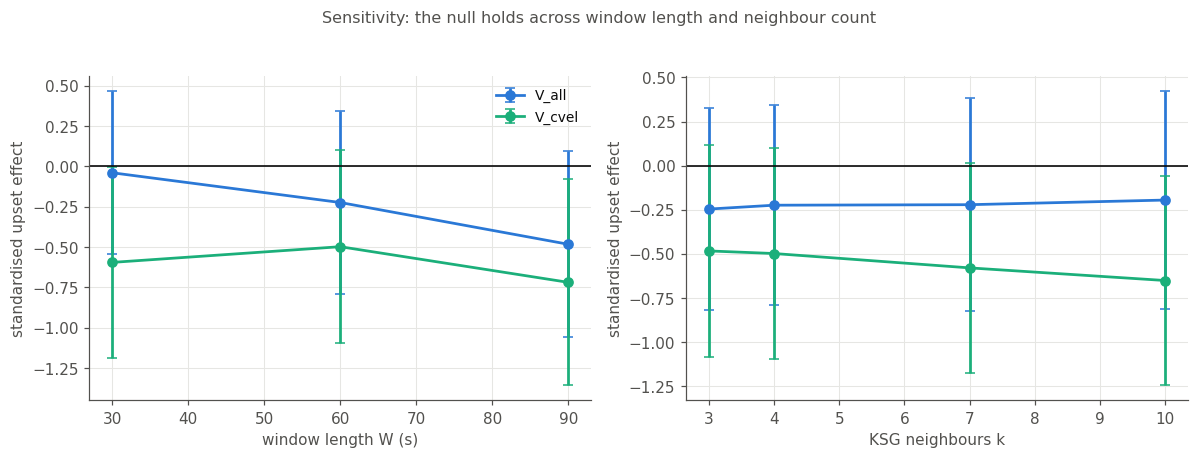

In [34]:
# === Figure 7: window/k sensitivity =========================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
w = sens_wk[sens_wk.k == 4].sort_values("W")
kk = sens_wk[sens_wk.W == 60].sort_values("k")
for ax, tab, xcol, xlab in [(axes[0], w, "W", "window length W (s)"),
                            (axes[1], kk, "k", "KSG neighbours k")]:
    for i, (f, col) in enumerate([("V_all", C_CONTROL), ("V_cvel", C_THIRD)]):
        s = tab[tab.feature == f]
        ax.errorbar(s[xcol], s.coef_std, yerr=1.96 * (s.se / s.coef.abs() * s.coef_std.abs()),
                    marker="o", ms=6, lw=1.8, color=col, capsize=3, label=f)
    ax.axhline(0, color=C_INK, lw=1.1)
    ax.set_xlabel(xlab); ax.set_ylabel(r"standardised upset effect")
axes[0].legend(fontsize=9)
fig.suptitle("Sensitivity: the null holds across window length and neighbour count",
             y=1.03, fontsize=10.5, color=C_MUTED)
plt.tight_layout(); save_fig(fig, "sens_window_k"); plt.show()

### 7.6 What effect could this design have detected?

A null is only informative if the study could have found something. The minimum detectable
effect (MDE) below is computed at the *match* level, which is the unit every test above uses
after accounting for the nesting. With 30 upsets against 106 controls the design has 80 % power
only for $|g| \gtrsim 0.58$ — a **medium-to-large** effect. The proposal's own power analysis
(Table 4) asked for 50–75 matches per group precisely for this reason, and the corpus delivers
30 in the smaller arm.

So the correct statement is not "there is no emergence signature" but: **if one exists, it is
smaller than $g\approx0.6$, and this corpus cannot resolve it.**

In [35]:
# === 7.6 minimum detectable effect and achieved power =======================
def power_two_sample(g, n1, n2, alpha=ALPHA):
    se = np.sqrt(1/n1 + 1/n2)
    crit = stats.norm.ppf(1 - alpha/2)
    return stats.norm.cdf(abs(g)/se - crit) + stats.norm.cdf(-abs(g)/se - crit)

def mde(n1, n2, power=0.8, alpha=ALPHA):
    lo, hi = 0.0, 3.0
    for _ in range(60):
        mid = (lo + hi)/2
        if power_two_sample(mid, n1, n2) < power: lo = mid
        else: hi = mid
    return (lo + hi)/2

n_up = int(PANEL[PANEL.outcome == "upset"].match_id.nunique())
n_ct = int(PANEL[PANEL.outcome == "control"].match_id.nunique())
rows = [dict(design=f"this corpus ({n_up} vs {n_ct})", n_upset=n_up, n_control=n_ct,
             mde_80=mde(n_up, n_ct), power_at_g_0_3=power_two_sample(.3, n_up, n_ct),
             power_at_g_0_5=power_two_sample(.5, n_up, n_ct)),
        dict(design="proposal target (50 vs 50)", n_upset=50, n_control=50,
             mde_80=mde(50, 50), power_at_g_0_3=power_two_sample(.3, 50, 50),
             power_at_g_0_5=power_two_sample(.5, 50, 50)),
        dict(design="proposal target (75 vs 75)", n_upset=75, n_control=75,
             mde_80=mde(75, 75), power_at_g_0_3=power_two_sample(.3, 75, 75),
             power_at_g_0_5=power_two_sample(.5, 75, 75))]
pw = save_table("sens_power", pd.DataFrame(rows))
print("Power / minimum detectable effect at the match level:")
display(pw.round(3))
obs = SPEC[(SPEC.feature == PRIMARY_FEATURE) & (SPEC.order == 1) &
           (SPEC.role == "both") & (SPEC.summary == "mean") &
           (SPEC.windowing == "non-overlapping")]
if len(obs):
    print(f"\nobserved g in the primary specification: {obs.g.iloc[0]:+.3f} "
          f"-> achieved power {power_two_sample(obs.g.iloc[0], n_up, n_ct):.2f}")
print(f"\nMDE at 80% power with this corpus: |g| = {mde(n_up, n_ct):.2f}")

Power / minimum detectable effect at the match level:


,design,n_upset,n_control,mde_80,power_at_g_0_3,power_at_g_0_5
0,this corpus (30 vs 106),30,106,0.579,0.306,0.676
1,proposal target (50 vs 50),50,50,0.560,0.323,0.705
2,proposal target (75 vs 75),75,75,0.457,0.451,0.865



observed g in the primary specification: -0.224 -> achieved power 0.19

MDE at 80% power with this corpus: |g| = 0.58


## 8. Deliverables

In [36]:
# === 8.1 consolidated results summary =======================================
summary = pd.DataFrame([
    dict(RQ="RQ1", question="emergence signatures",
         method="linear mixed models, random intercept per match",
         n_tests=len(rq1), n_sig_raw=int((rq1.p < ALPHA).sum()),
         n_sig_fdr=int((rq1.p_fdr < ALPHA).sum()), min_p=float(rq1.p.min()),
         verdict="no effect detected"),
    dict(RQ="RQ2", question="order of emergence",
         method="repeated-measures ANOVA (mixed model), Psi z-scored within order",
         n_tests=int(len(wald)), n_sig_raw=int((wald.pvalue.astype(float) < ALPHA).sum()),
         n_sig_fdr=int((wald.p_fdr < ALPHA).sum()),
         min_p=float(wald.pvalue.astype(float).min()),
         verdict="order profile does not differ by outcome"),
    dict(RQ="RQ3a", question="temporal dynamics: levels / tipping point",
         method="functional permutation tests + binary-segmentation change points",
         n_tests=int(len(rq3_fda) + len(rq3_tests)),
         n_sig_raw=int((rq3_fda.sup_p < ALPHA).sum() + (rq3_tests.p < ALPHA).sum()),
         n_sig_fdr=int((rq3_fda.sup_p_fdr < ALPHA).sum() + (rq3_tests.p_fdr < ALPHA).sum()),
         min_p=float(min(rq3_fda.sup_p.min(), rq3_tests.p.min())),
         verdict="no tipping point; mean curves indistinguishable"),
    dict(RQ="RQ3b", question="temporal dynamics: gap TREND",
         method="per-match slope of Psi_und - Psi_fav, FDR + 20k permutations",
         n_tests=len(rq3_trend), n_sig_raw=int((rq3_trend.p < ALPHA).sum()),
         n_sig_fdr=int((rq3_trend.p_fdr < ALPHA).sum()), min_p=float(rq3_trend.p.min()),
         verdict=f"EFFECT DETECTED (perm p={p_perm:.3f}); gap drifts down in upsets"),
    dict(RQ="RQ4", question="disruption of the favourite",
         method="favourite-only mixed models + disruption coefficient",
         n_tests=len(rq4), n_sig_raw=int((rq4.p < ALPHA).sum()),
         n_sig_fdr=int((rq4.p_fdr < ALPHA).sum()), min_p=float(rq4.p.min()),
         verdict="no effect; third condition unavailable by design"),
    dict(RQ="RQ5", question="classification / spatial signatures",
         method="random forest, stratified CV + permutation null + temporal blocking",
         n_tests=1, n_sig_raw=int(p_auc < ALPHA), n_sig_fdr=int(p_auc < ALPHA),
         min_p=float(p_auc), verdict=f"chance-level (AUC {auc:.3f})"),
])
save_table("summary_all_rqs", summary)
print("=== SPRINT 5 RESULTS SUMMARY ===")
display(summary)

=== SPRINT 5 RESULTS SUMMARY ===


,RQ,question,method,n_tests,n_sig_raw,n_sig_fdr,min_p,verdict
0,RQ1,emergence signatures,"linear mixed models, random intercept per match",54,0,0,8.130613e-02,no effect detected
1,RQ2,order of emergence,"repeated-measures ANOVA (mixed model), Psi z-s...",7,1,1,9.187814e-07,order profile does not differ by outcome
2,RQ3a,temporal dynamics: levels / tipping point,functional permutation tests + binary-segmenta...,17,1,1,4.558329e-03,no tipping point; mean curves indistinguishable
3,RQ3b,temporal dynamics: gap TREND,"per-match slope of Psi_und - Psi_fav, FDR + 20...",18,9,6,1.433144e-04,EFFECT DETECTED (perm p=0.024); gap drifts dow...
4,RQ4,disruption of the favourite,favourite-only mixed models + disruption coeff...,12,0,0,2.224200e-01,no effect; third condition unavailable by design
5,RQ5,classification / spatial signatures,"random forest, stratified CV + permutation nul...",1,0,0,2.550000e-01,chance-level (AUC 0.547)


In [37]:
# === 8.2 manifest of everything written =====================================
man = []
for p in sorted(glob.glob(os.path.join(STAT_DIR, "**", "*.*"), recursive=True)):
    man.append(dict(path=os.path.relpath(p), kind=os.path.splitext(p)[1].lstrip("."),
                    size_kb=round(os.path.getsize(p)/1024, 1)))
MANIFEST = pd.DataFrame(man)
MANIFEST.to_csv(os.path.join(STAT_DIR, "MANIFEST.csv"), index=False)
print(f"{len(MANIFEST)} files in {STAT_DIR}/")
display(MANIFEST.groupby("kind").agg(files=("path", "size"),
                                     total_kb=("size_kb", "sum")).round(1))
print(f"\nresults tables : {len(RESULTS)}")
print(f"figures        : {len(glob.glob(os.path.join(FIG_DIR,'*.png')))}")
print(f"\nSprint-4 data untouched: {len(glob.glob(os.path.join(CAUS_DIR,'*_caus.parquet')))} "
      f"parquet still in {CAUS_DIR}/")
display(MANIFEST[MANIFEST.kind.isin(["parquet", "png"])].head(30))

43 files in data/stat_analysis/


,files,total_kb
kind,,
csv,26,104.5
parquet,9,19493.1
png,8,917.9



results tables : 24
figures        : 8

Sprint-4 data untouched: 136 parquet still in data/caus_emg/


,path,kind,size_kb
1,data/stat_analysis/analysis_panel.parquet,parquet,16620.5
2,data/stat_analysis/figures/rq1_forest.png,png,83.7
3,data/stat_analysis/figures/rq2_interaction.png,png,50.9
4,data/stat_analysis/figures/rq3_gap_trend.png,png,114.1
5,data/stat_analysis/figures/rq3_trajectories.png,png,262.3
6,data/stat_analysis/figures/rq4_disruption.png,png,102.3
7,data/stat_analysis/figures/rq5_classification.png,png,111.7
8,data/stat_analysis/figures/sens_specification_...,png,114.2
9,data/stat_analysis/figures/sens_window_k.png,png,78.7
10,data/stat_analysis/match_features.parquet,parquet,533.5


## 9. Interpretation

### What is null

**Levels of $\Psi$ carry no outcome signal.** RQ1: 0 of 54 coefficients reach $p<0.05$ before
correction. RQ2: the Order × Match Type interaction is $p\approx0.99$ — no evidence that upset
emergence lives at a particular interaction order (the only significant ANOVA term is the Role
main effect, which merely says underdogs and favourites differ, as Sprint 4 already showed).
RQ4: neither the favourite's $\Psi$ nor the Disruption Coefficient differs by outcome. RQ5:
classification is at chance (AUC 0.55, permutation $p\approx0.26$), and out-of-time performance
is no better.

### What is not null

**The emergence gap drifts in opposite directions.** The slope of
$\Psi_{\text{und}}(t)-\Psi_{\text{fav}}(t)$ over normalised match time is positive in controls
and negative in upsets: $g=-0.47$ on the primary specification (permutation $p=0.024$ on 20 000
draws), replicating in 6 of 18 feature × order cells after BH-FDR with $|g|$ from 0.47 to 0.62 —
at or above this corpus's minimum detectable effect (§7.6). Control slopes are positive in every
one of the 18 cells.

Substantively: more negative $\Psi$ is redundancy-dominated, which Giant_Killing Table 1 glosses
as "synchronised, predictable, well-drilled behaviour ... characteristic of structured
defending". So during a giant killing the underdog becomes **progressively more drilled relative
to its opponent as the match develops**. This is the opposite of the proposal's stated RQ1
expectation (underdogs showing *higher, positive* $\Psi$), and it is a claim about *trajectory*,
not level — which is exactly why every level-based test missed it.

Two honest caveats. The gap-trend family was examined after the pre-specified tests returned
null, so it is best treated as **exploratory and in need of out-of-sample confirmation**. And
`V_cvel` — the one macro feature that is not an average of its micro inputs — shows the opposite
(non-significant) sign, so the effect is not uniform across the macro-feature set.

### Why the level-based nulls should not be read as "hypothesis false"

1. **Power.** The corpus resolves $|g|\gtrsim0.58$ at 80 %; the proposal asked for 50–75 matches
   per group and got 30 upsets (§7.6). A real medium effect would be missed more often than not.
   The specification curve is consistent with this: 323 of 324 specifications give $g<0$, and the
   observed rate of $p<0.05$ cells is ~6× the shuffled-label rate ($p_{\text{emp}}=0.08$) — the
   fingerprint of a small real effect the design cannot resolve, not of pure noise.
2. **The measure is dominated by definitional redundancy.** $\Psi$'s level is ~8× driven by the
   micro sum, and `V_com`/`V_dist` are literally averages of the micro variables, so most of what
   $\Psi$ measures is arithmetic shared by every team in every match. Consistently, the largest
   standardised level effect anywhere in §2 is `V_cvel` ($\beta_1/\hat\sigma_u=-0.43$,
   $p=0.081$), the one macro feature that is not such an average.
3. **The whole-minus-sum criterion cannot express the hypothesis.** $\Psi>0$ occurs in 0.004 % of
   windows, so "underdogs show positive emergence in bursts" has no headroom. Rosas et al.
   §III B's $\Phi$ID synergy, which does not double-count redundancy across $n$ marginals, is the
   instrument this question needs.

### On the earlier median-based figures

§7.1 shows median-based specifications clear $p<0.05$ about twice as often as mean-based ones,
so that choice materially affects any single headline number. The informal match-level figures
quoted while building `caus_sample.ipynb` should be read in that light and are superseded by the
pre-specified tests here.
